# Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. 

The idea is that the mask pixels can be iteratively changed to minimize of a loss function which evaluates the simulated propagated field from the mask against a target response. A gradient descent method changes the mask pixels iteratively in the direction of the gradient until a certain tolerance is met. Some metrics can be used for loss function constructions. Examples of simple loss functions are the root mean square error (RMSE) or the maximum likelihood estimator. pyMOE optimize module calculates the gradient through JAX package, employing scipy or optax (JAX) optimization frameworks, being extremelly versatile, allowing the user to pick different propagation methods for the task.    

Further documentation will be updated in future releases 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [2]:
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 

In [3]:
# auto reload
%load_ext autoreload
%autoreload 2

In [4]:
#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m

## Initializations

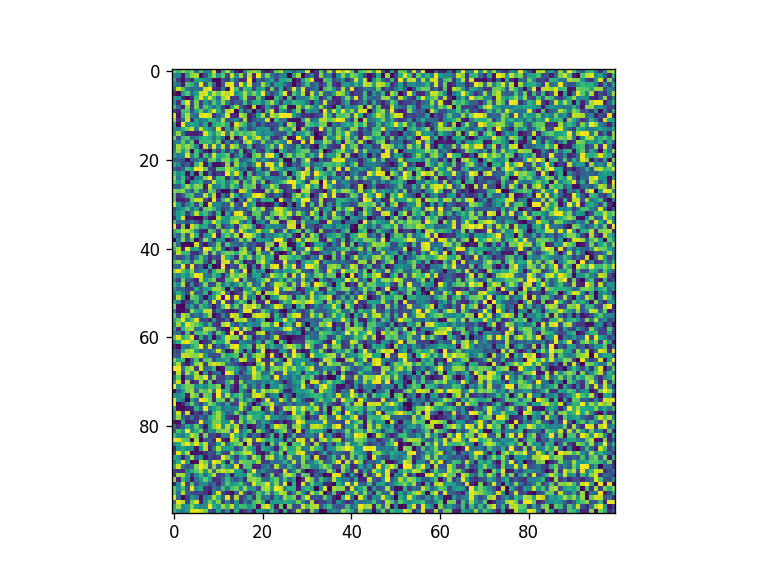

In [5]:
#Create initial random pixel distribution 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

fig = plt.figure() 
plt.imshow(x0)

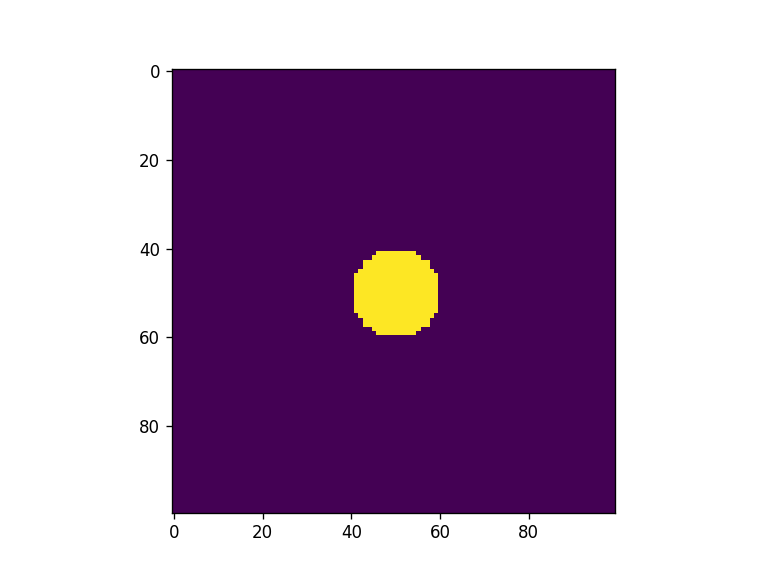

In [6]:
#create target matrix (central cricular pattern) 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)

target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.imshow(target)

## Optimization framework

The optimization framework passes through the definition of loss functions. Here simply they compare the propagation against a defined target. The loss function takes the propagation method as parameter, so it that different parameters can be tested. 

In [7]:
#Define loss functions 
def mseloss(x, mask, screen, wavelength, target, propag="bluestein"): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    
    diff = jnp.abs(prop_x/jnp.sum(prop_x) - target/jnp.max(target))**2
     
    res = jnp.mean(diff)

    return res


def logloss(x, mask, screen, wavelength, target=target_flat, propag="bluestein"): 
    import jax.numpy as jnp 
    
    prop_x = jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag).flatten())
    prop_x = jnp.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    target = jnp.reshape(target, (x_pixel, y_pixel))
    
    res = jnp.log(np.sum(((prop_x/jnp.max(prop_x)/(prop_x[(midx,midy)]/jnp.max(prop_x)) - target/jnp.max(target))**2)))
    
    return res

In [8]:
# Create Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

In [9]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] at zdist 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

zdist = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

In [10]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=[aperture, screen, wavelength, target], verbose = 1, ftol=1e-4, )

Elapsed: 0:00:01.048897
Elapsed: 0:00:00.299189
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.013940
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013940
Elapsed: 0:00:00.048786
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.051773
Elapsed: 0:00:00.014438
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013441
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.044306
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039329
`ftol` termination condition is satisfied.
Function evaluations 18, initial cost 4.6493e-04, final cost 4.6105e-04, first-order optimali

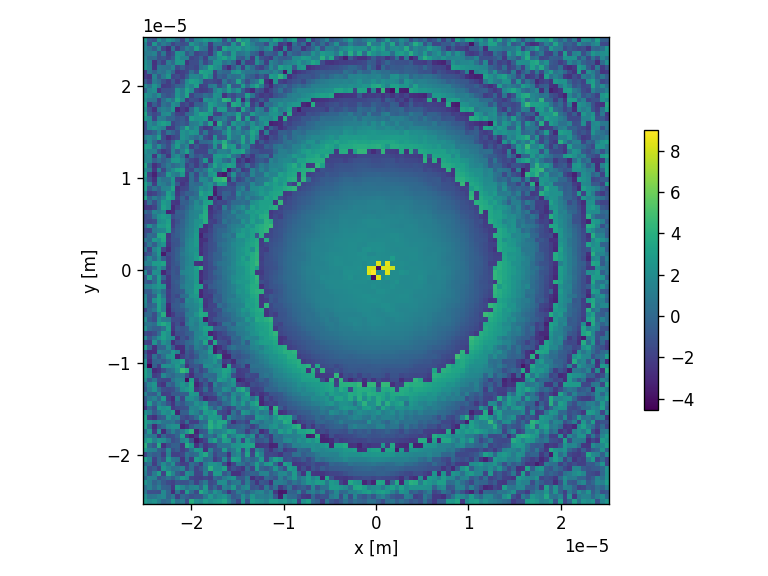

In [11]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.025886


Text(0.5, 1.0, 'Target')

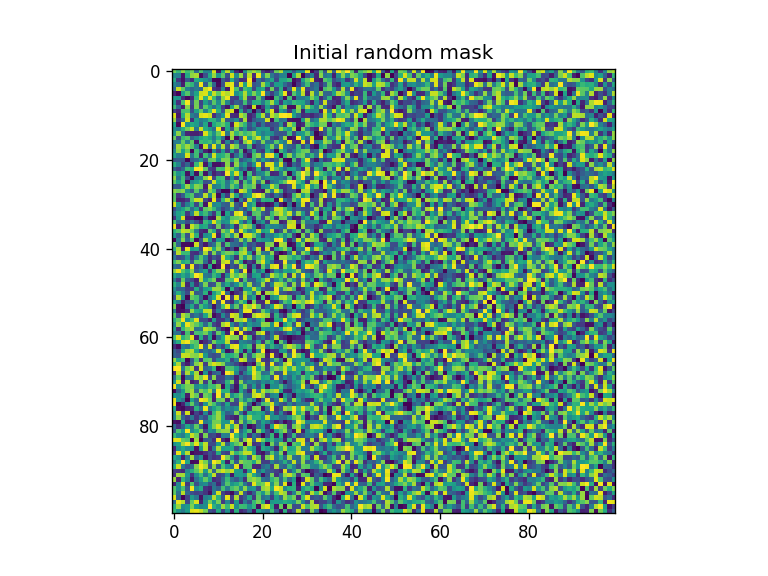

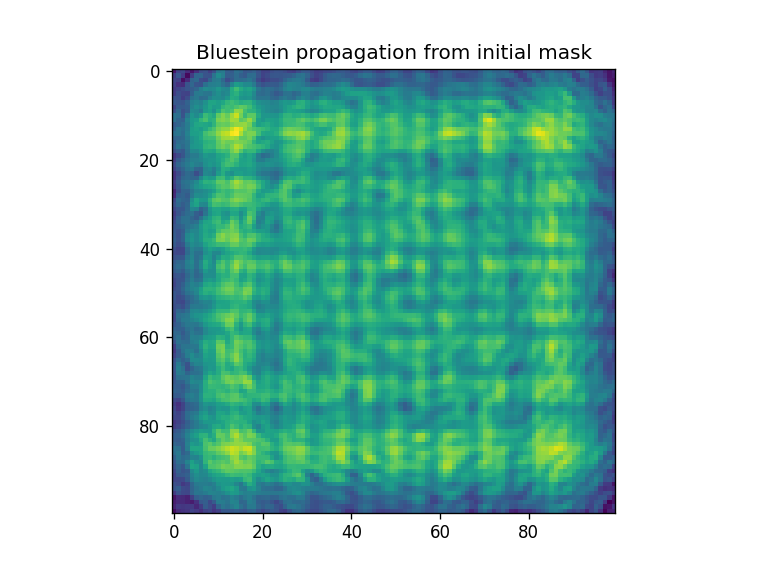

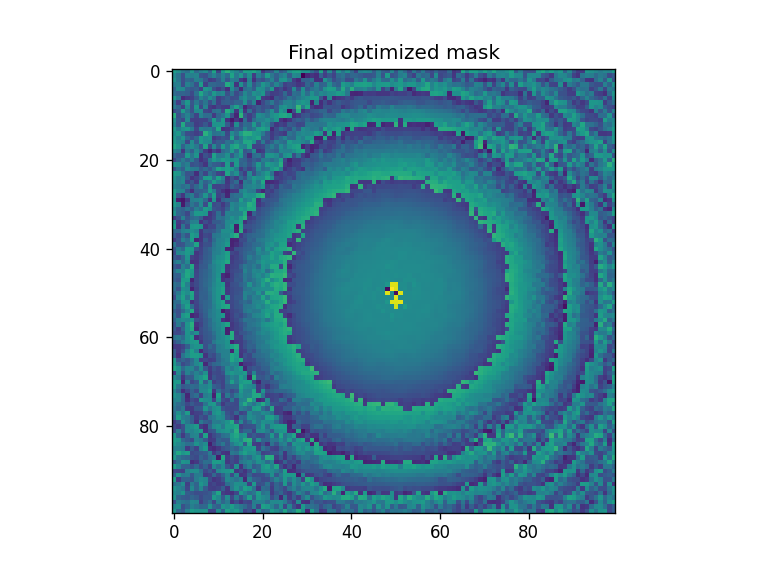

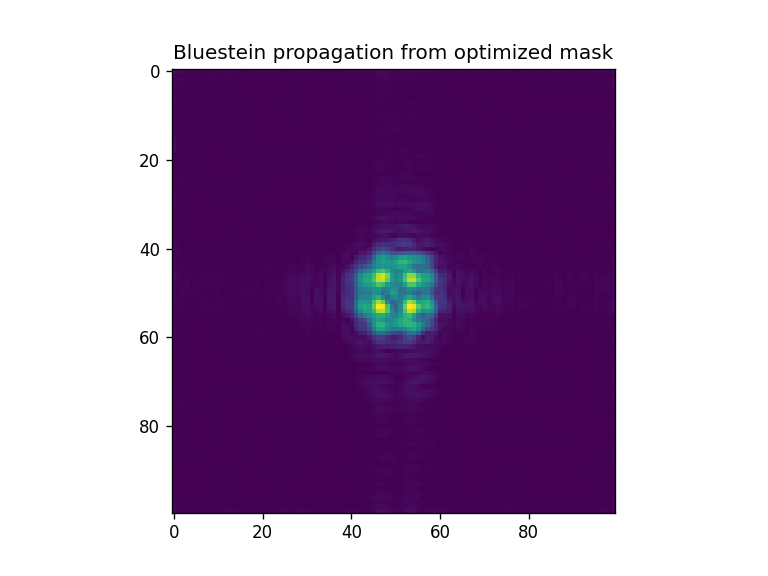

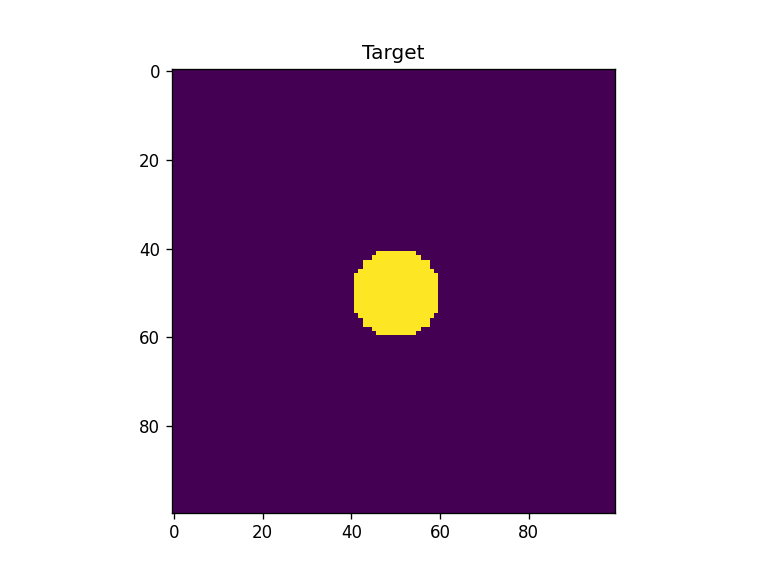

In [12]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

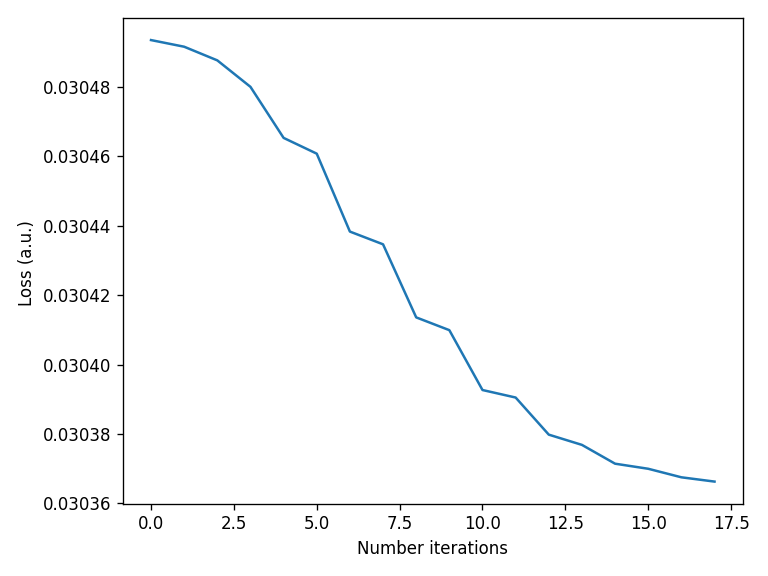

In [13]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

#### Optimization with logging 

The optimizer module provides an embedded logger to allow to track the optimization loss and store the parameters at each iteration step. 

In [14]:
# x0_flatten is your initial guess vector
logger, logfile_txt, logfile_bin, batch_list, iter_counter, batch_size, fh = moe.optimizer.setup_optimizer_logger_batch( x_size=len(x0_flatten), \
                                                                                                       batch_size=1, log_dir="logs", name="test")



In [15]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=[aperture, screen, wavelength, target], verbose = 1, ftol=1e-4, logger=logger, \
                                  logfile_bin=logfile_bin, batch_list=batch_list, batch_size=batch_size, iter_counter=iter_counter, fh=fh)

Elapsed: 0:00:00.014935
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.014933
Elapsed: 0:00:00.038331
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.042311
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.017423
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014428
Elapsed: 0:00:00.038331
Elapsed: 0:00:00.013441
Elapsed: 0:00:00.038333
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.037833
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038361
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.038830
`ftol` termination condition is satisfied.
Function evaluations 18, initial cost 4.6493e-04, final cost 4.6105e-04, first-order optimali

Elapsed: 0:00:00.014936
Elapsed: 0:00:00.014436


Text(0.5, 1.0, 'Target')

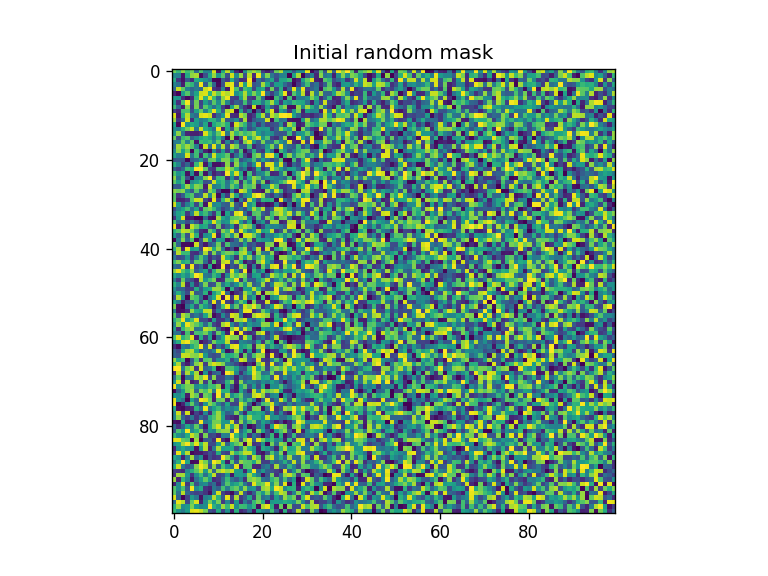

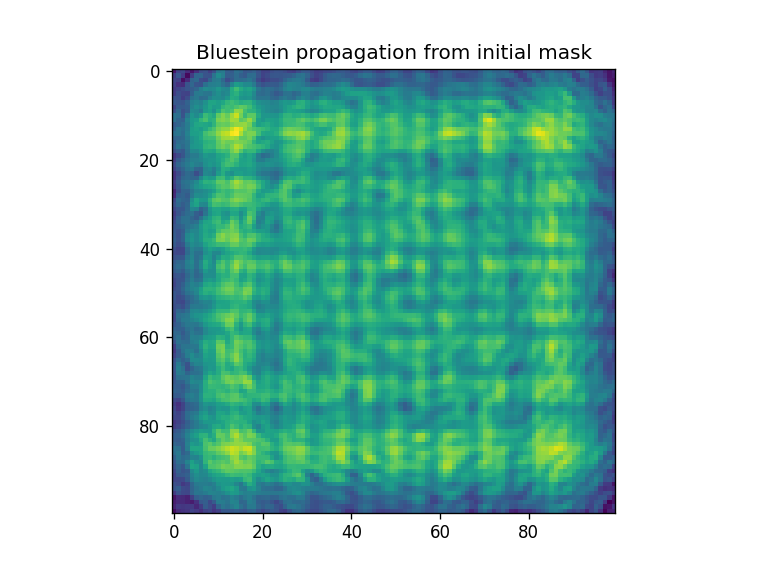

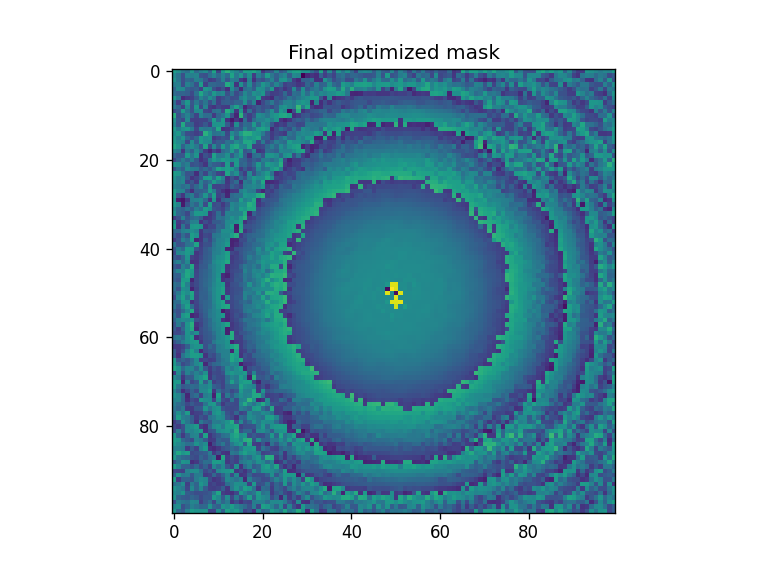

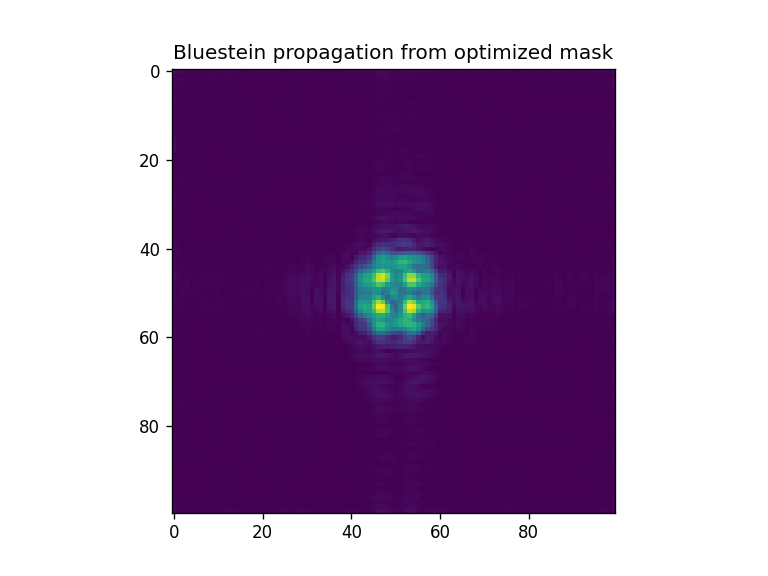

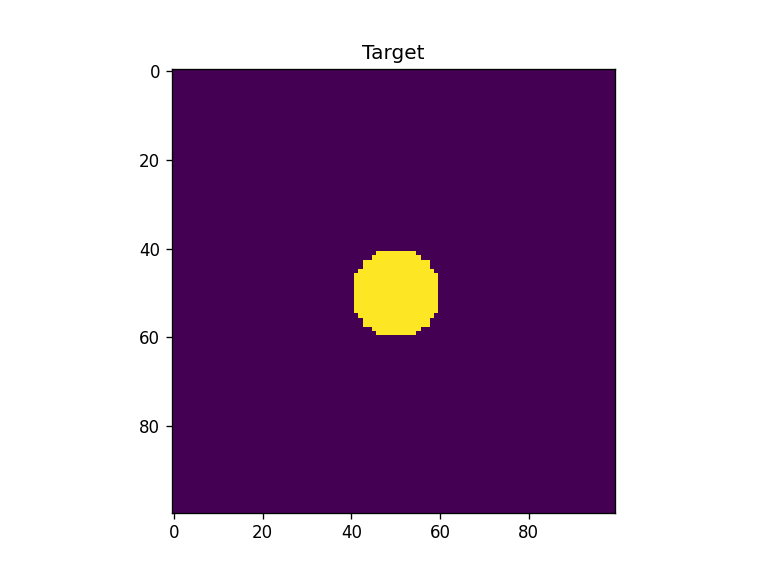

In [16]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

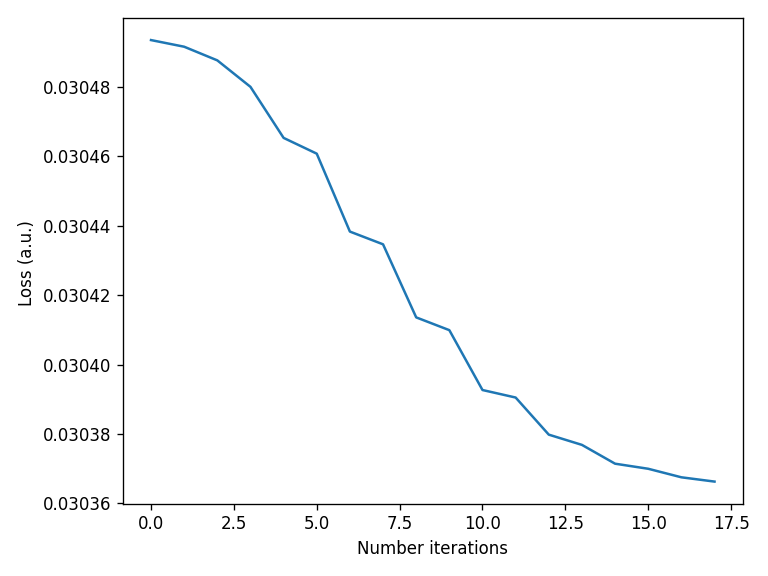

In [17]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Optimization with different forward propagators 

Below we demonstrate several optimizations using Bluestein, ASM and SASM propagators in the forward step. All of them yield acceptable inverse designed masks. 

#### Bluestein (default) 

In [18]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target], verbose = 1, ftol=1e-4, )

Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.015929
Elapsed: 0:00:00.039326
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.015433
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.015431
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.015433
Elapsed: 0:00:00.044306
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.015438
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014438
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.014936
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038332
Elapsed: 0:00:00.016428
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.039824
Elapsed: 0:00:00

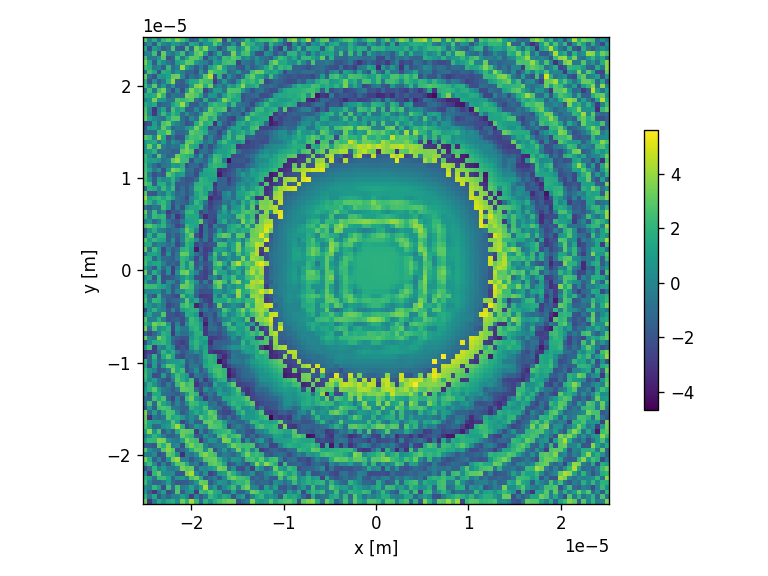

In [19]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.014935


Text(0.5, 1.0, 'Target')

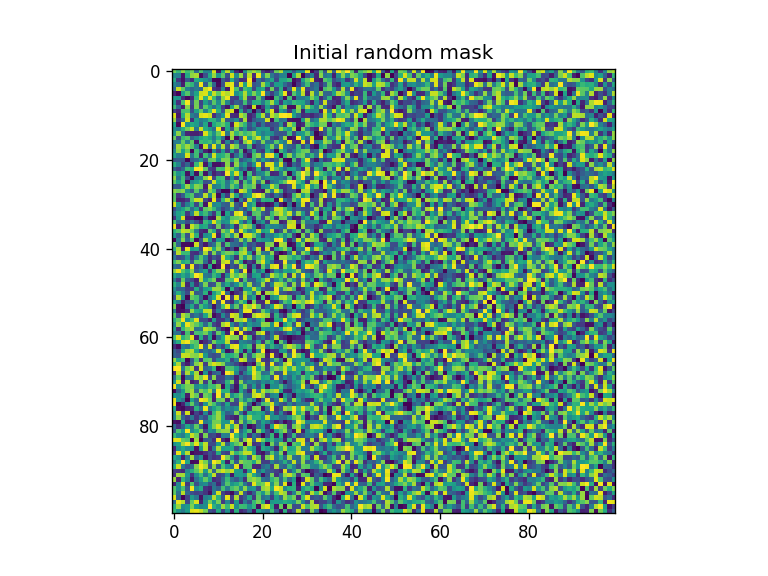

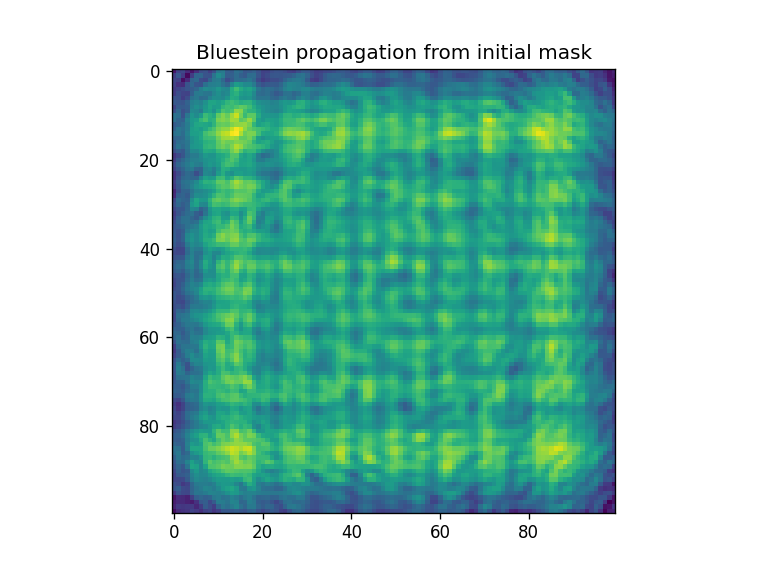

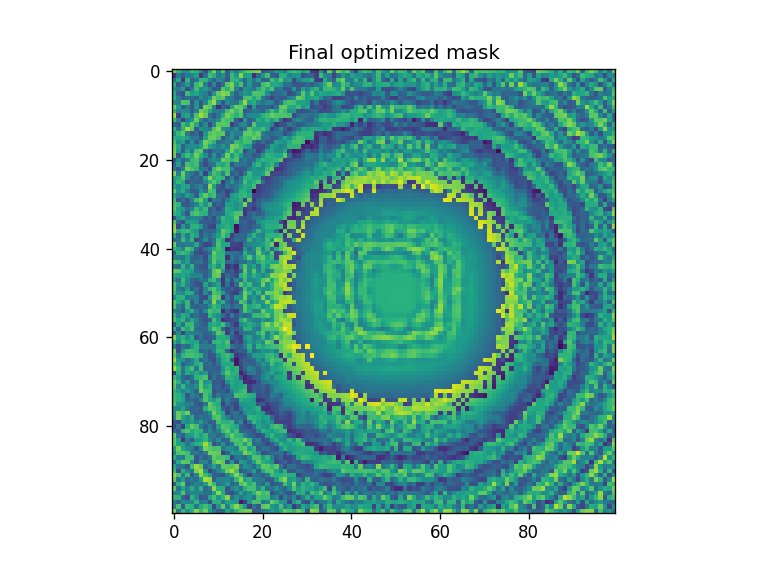

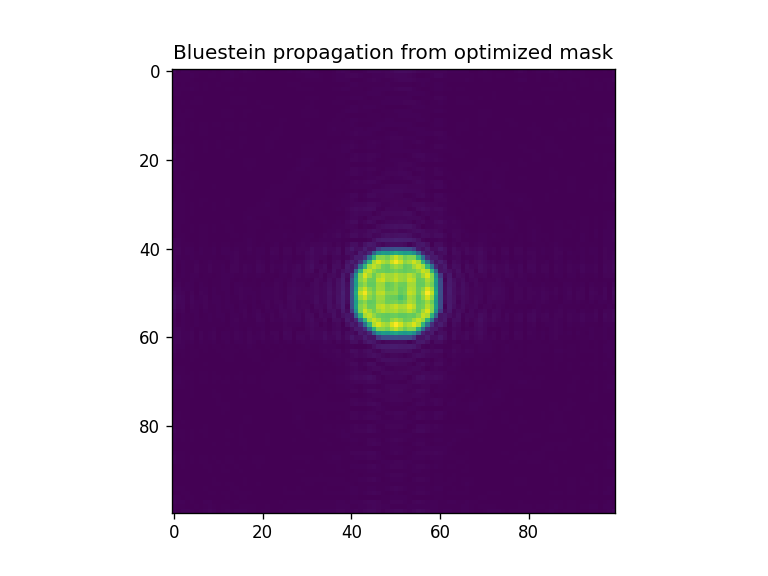

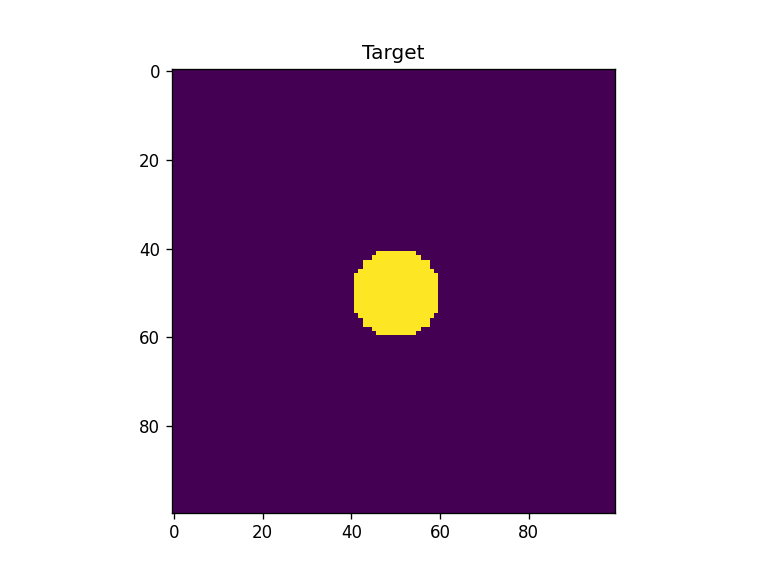

In [20]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

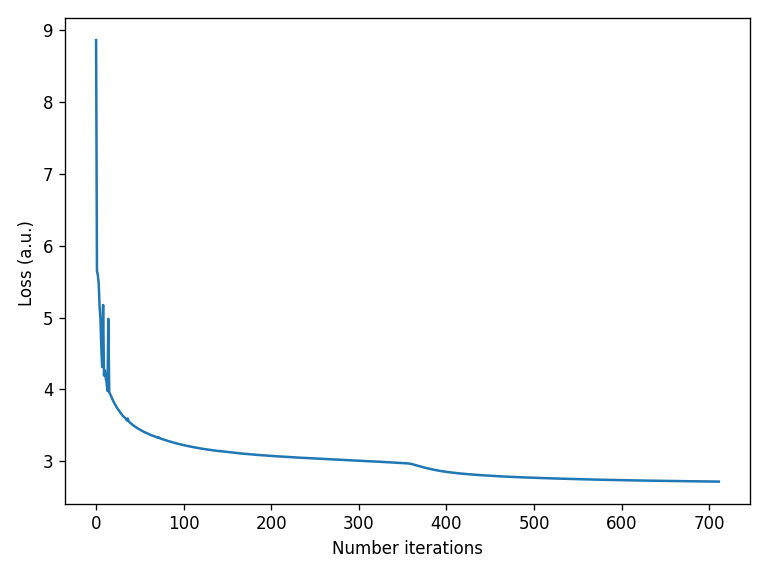

In [21]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

#### ASM

In [22]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target, "ASM"], verbose = 1, ftol=1e-4, )

C:\Users\jcunha377\AppData\Roaming\Python\Python311\site-packages\jax\_src\numpy\lax_numpy.py:148: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


Elapsed: 0:00:02.636424
Elapsed: 0:00:00.799991
Elapsed: 0:00:00.029370
Elapsed: 0:00:00.073676
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.027381
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.088612
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.067703
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.029869
Elapsed: 0:00:00.088114
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.070193
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.070193
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.071187
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.028375
Elapsed: 0:00:00

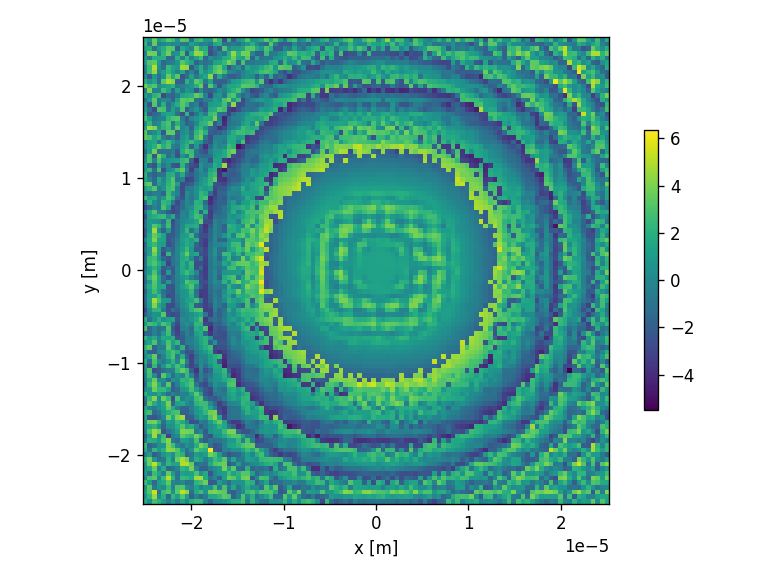

In [23]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.016933
Elapsed: 0:00:00.014437


Text(0.5, 1.0, 'Target')

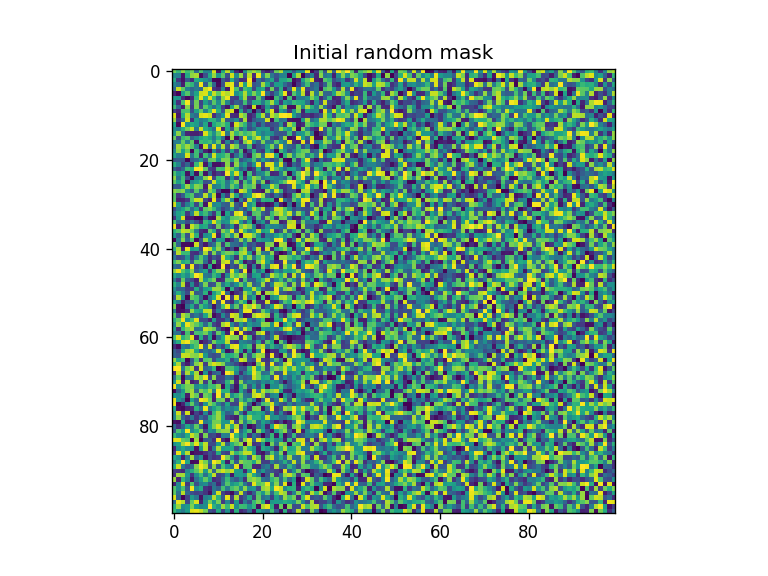

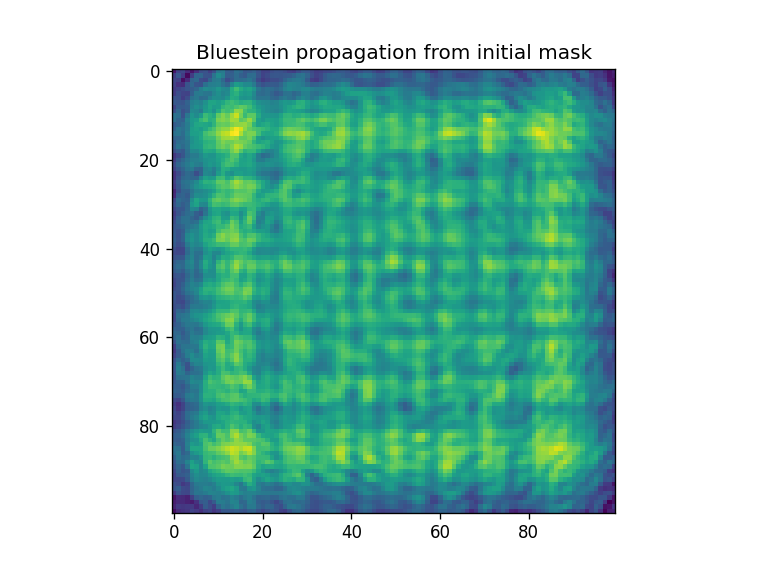

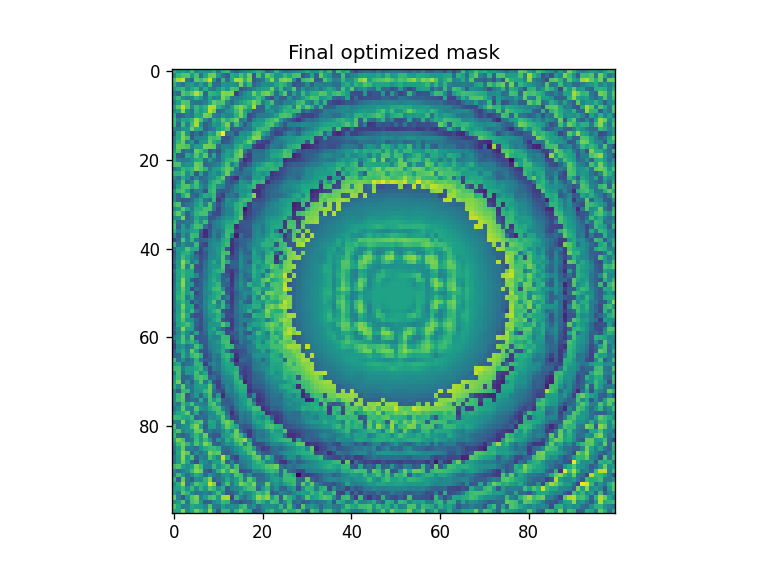

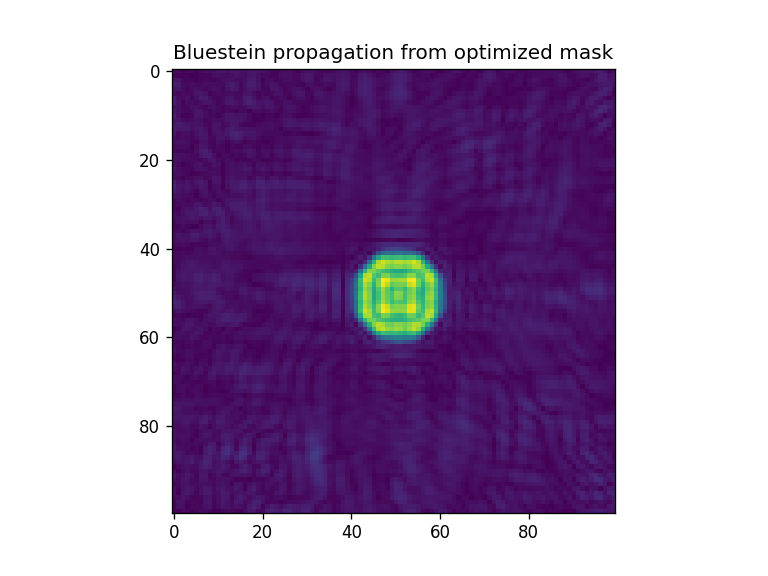

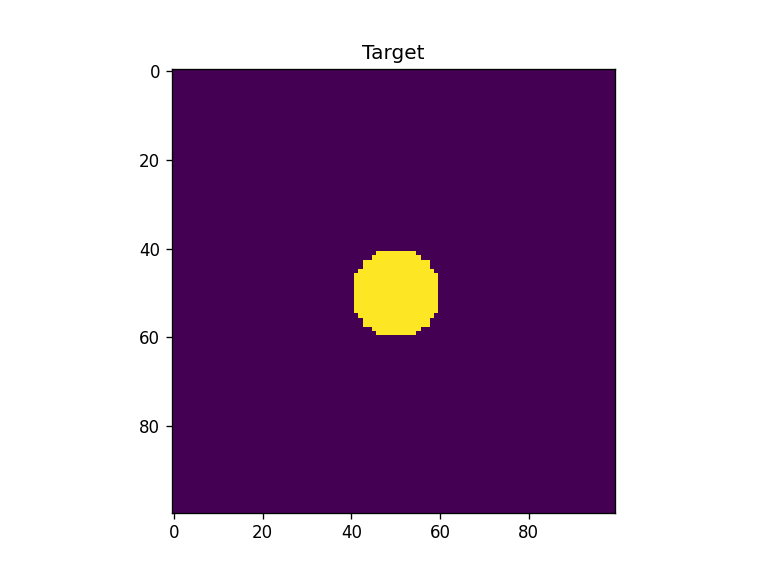

In [24]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

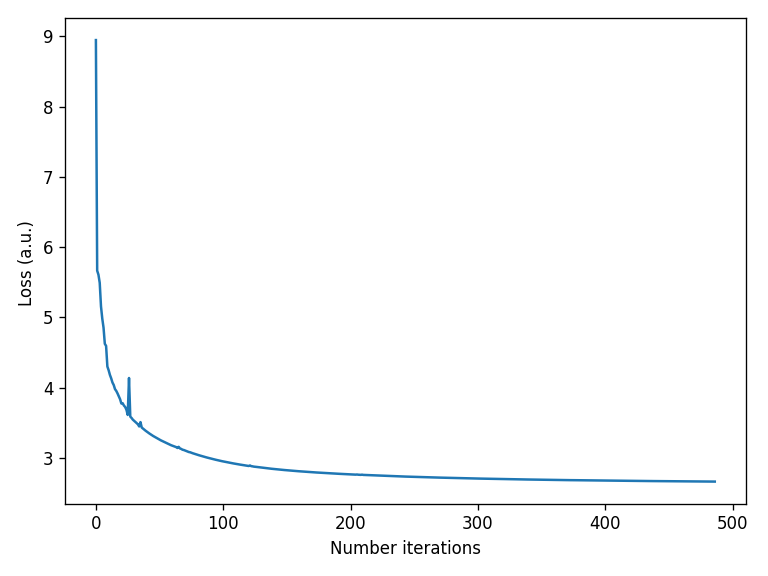

In [25]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

#### SASM

In [26]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randomly initialized x0 
solution = moe.optimizer.optimize(logloss, x0_flatten, args1=[aperture, screen, wavelength, target, "ASM"], verbose = 1, ftol=1e-4, )

Elapsed: 0:00:00.029371
Elapsed: 0:00:00.070691
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.071188
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.075171
Elapsed: 0:00:00.031861
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.089110
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.073677
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.075668
Elapsed: 0:00:00.030366
Elapsed: 0:00:00.088610
Elapsed: 0:00:00.034847
Elapsed: 0:00:00.068200
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.027379
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027877
Elapsed: 0:00:00

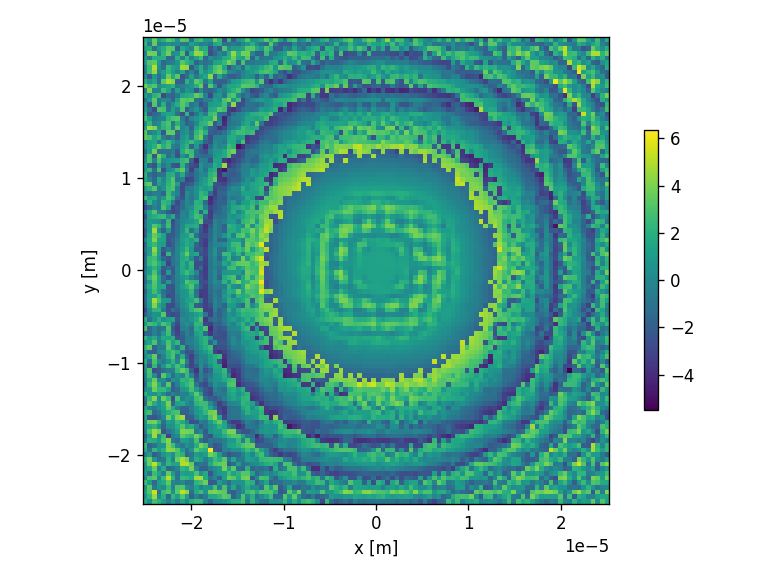

In [27]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.016428
Elapsed: 0:00:00.014934


Text(0.5, 1.0, 'Target')

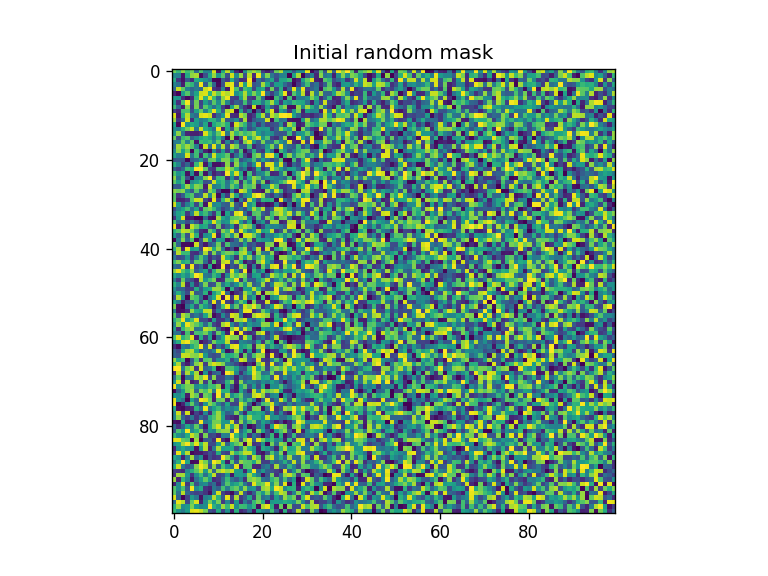

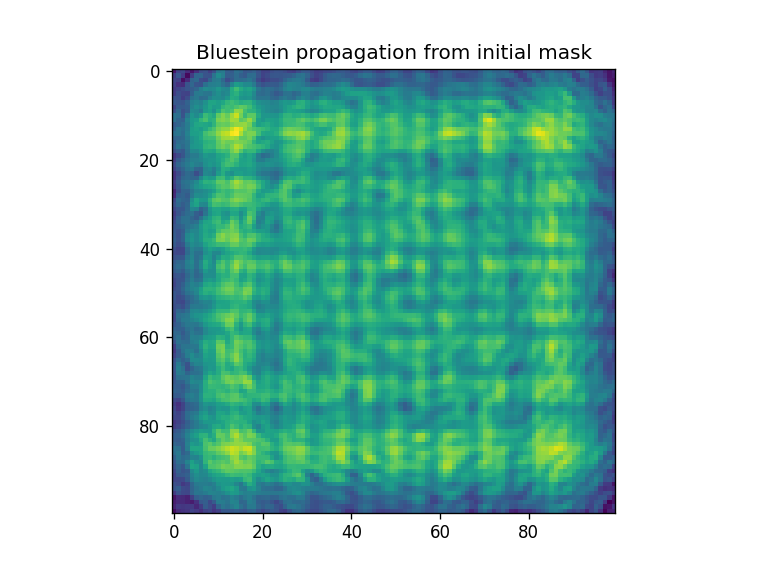

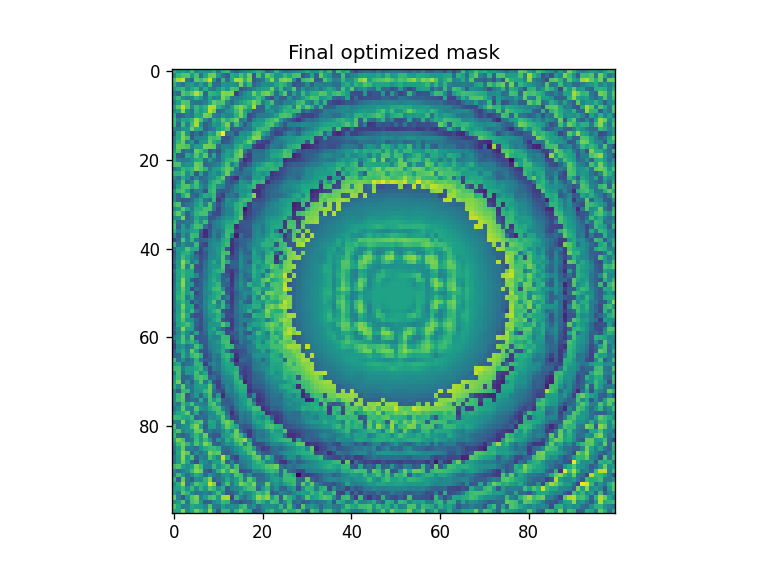

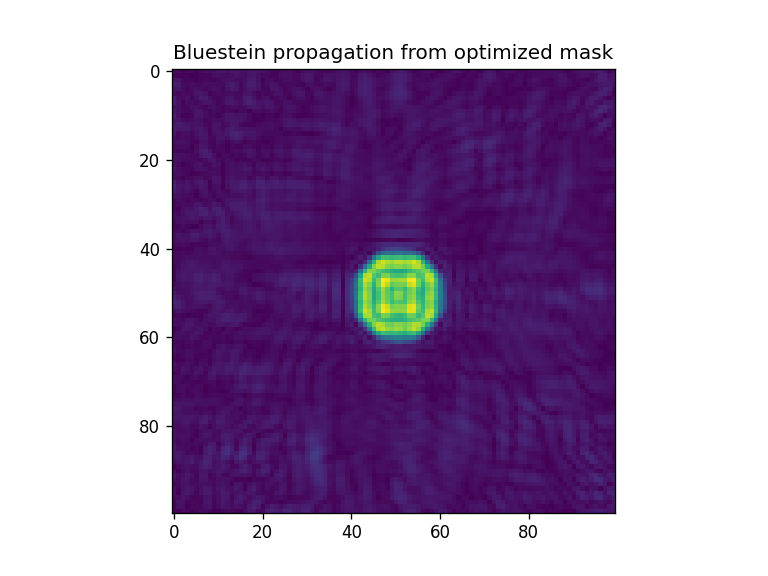

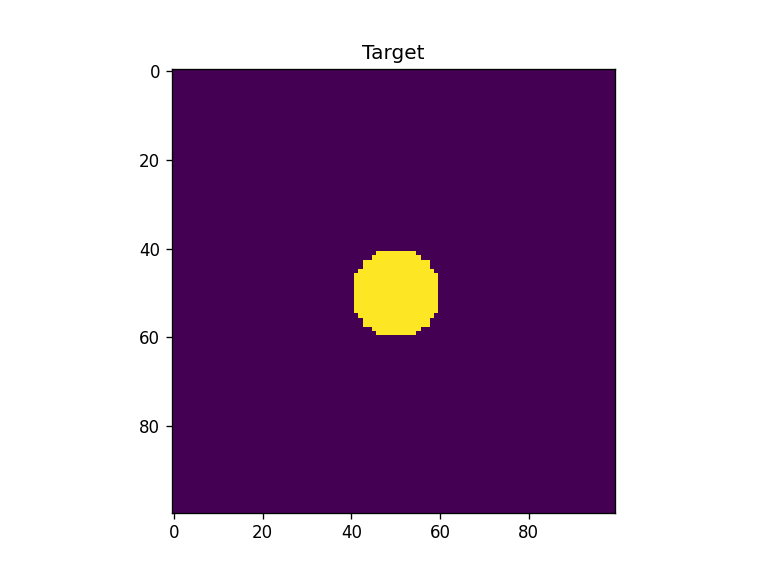

In [28]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

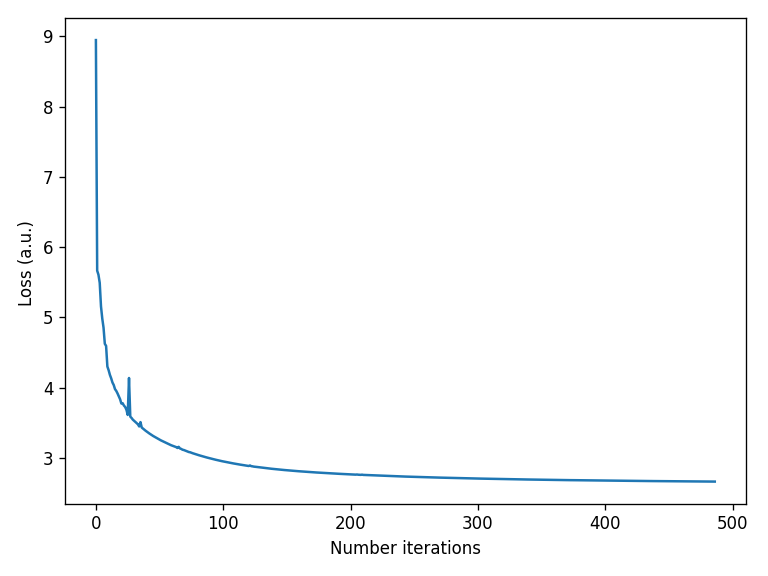

In [29]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Loss function engineering 
We can alter the loss function for whatever suits us best 

In [30]:
def logloss2(x, mask, screen, wavelength, target, propag): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag ))
    
    diff = jnp.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - target/jnp.max(target))**2
     
    res = jnp.log(jnp.sum(diff))

    return res

In [31]:
## Optimization with ASM 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=[aperture, screen, wavelength, target, "ASM"], verbose = 1, ftol=1e-6,)

Elapsed: 0:00:00.029370
Elapsed: 0:00:00.086122
Elapsed: 0:00:00.029866
Elapsed: 0:00:00.099066
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.029372
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.028374
Elapsed: 0:00:00.069197
Elapsed: 0:00:00.027879
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.068700
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.072184
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.070193
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.073179
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.072183
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.067703
Elapsed: 0:00:00.029869
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027379
Elapsed: 0:00:00

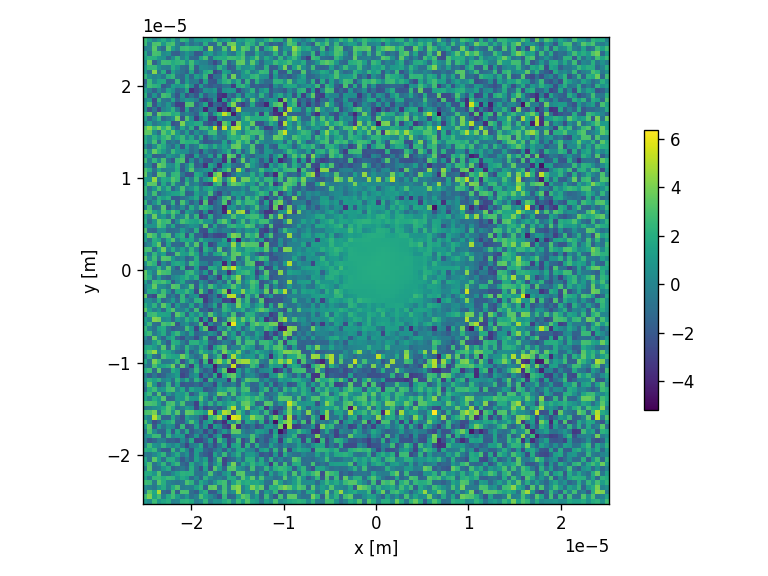

In [32]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))

#just for plotting the phase with dimensions 
aperture.aperture = xar 
moe.plotting.plot_aperture(aperture)

Elapsed: 0:00:00.014932
Elapsed: 0:00:00.025389


Text(0.5, 1.0, 'Target')

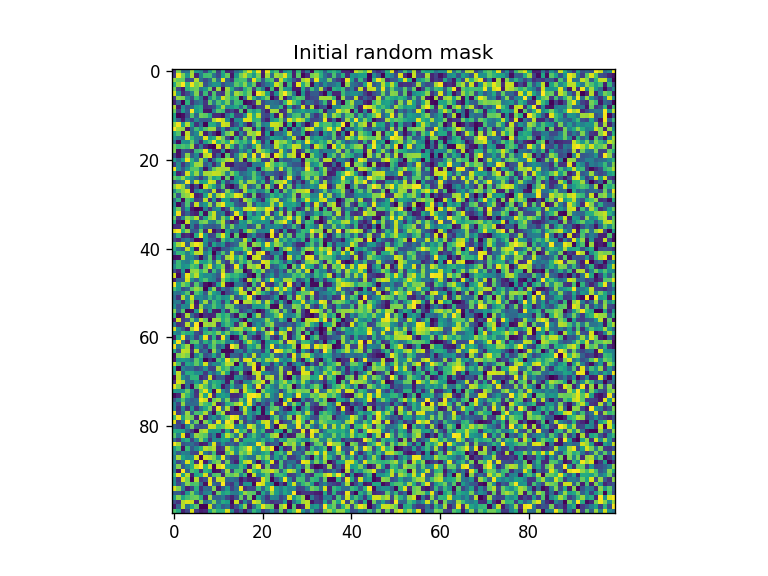

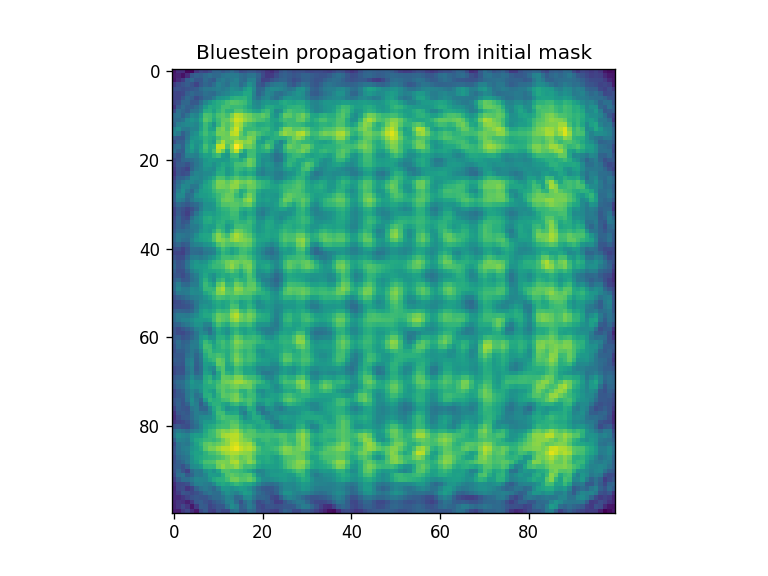

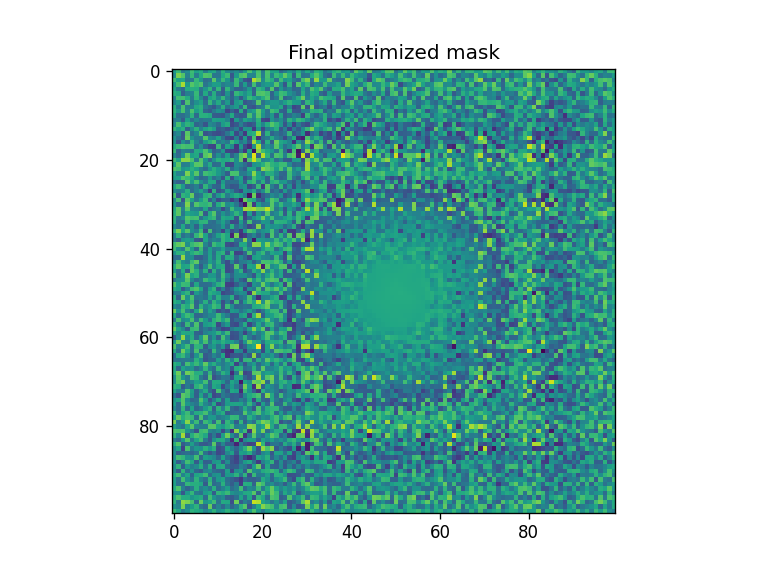

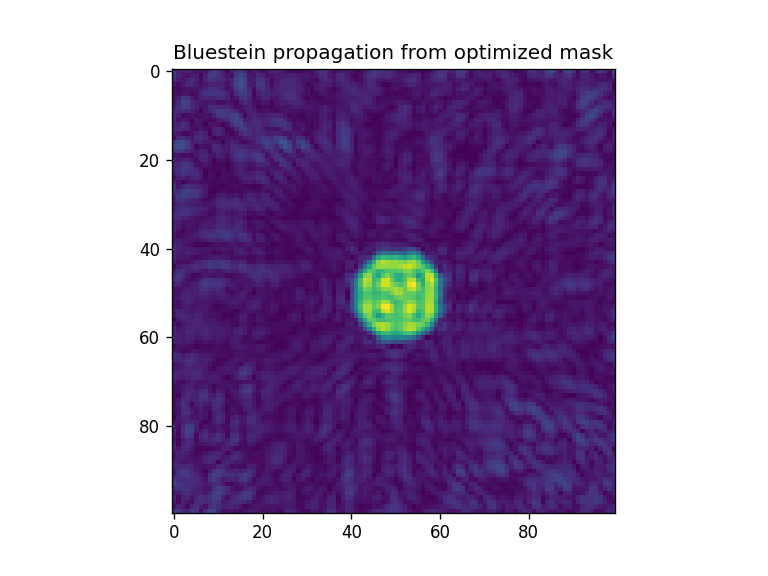

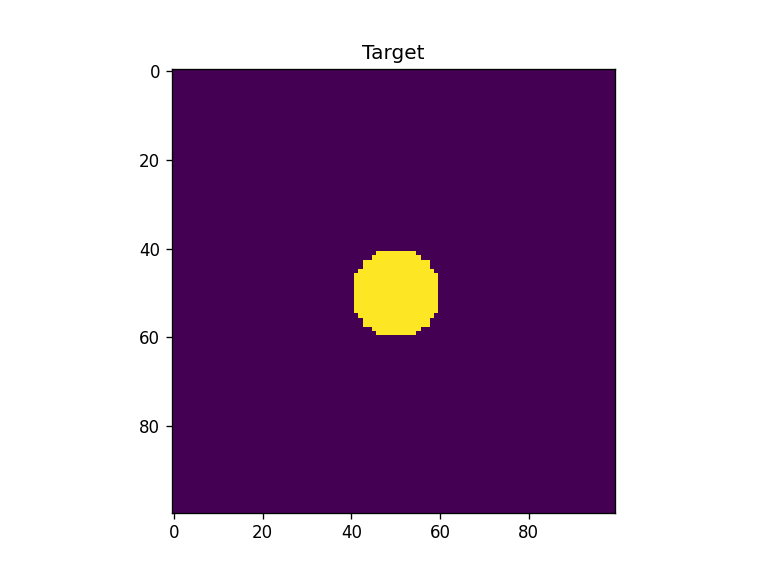

In [33]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

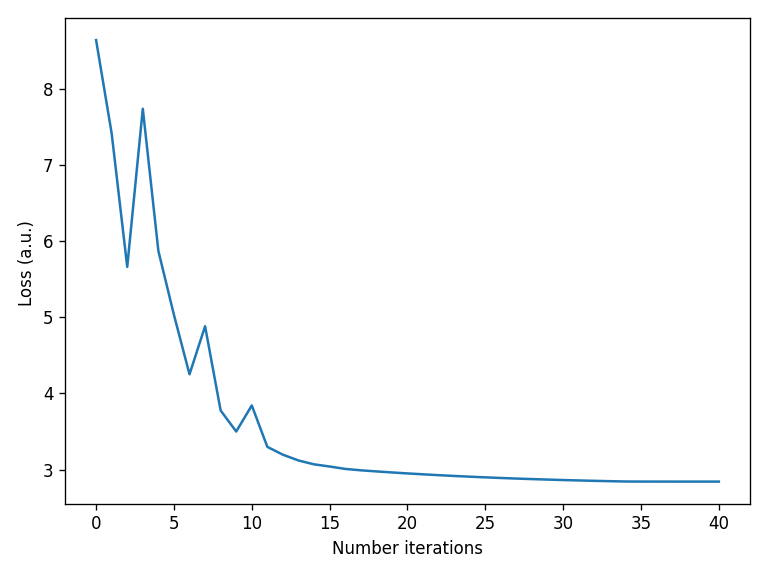

In [34]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Target re-definition 
We can alter the target for what we desire. The target can be generated from analytical or theoretical models, e.g. it could be generated as Airy pattern or Gaussian-Laguerre beam profile. 

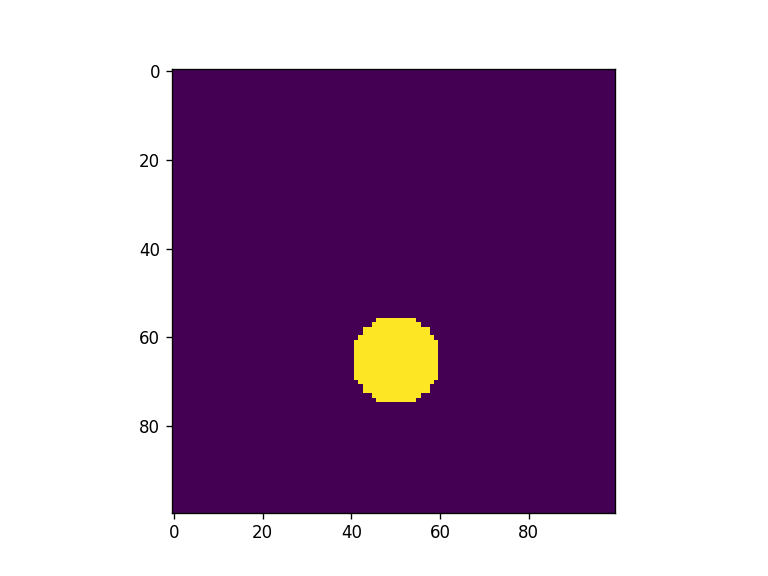

In [35]:
# re-define  target 

#target with offset circle 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel*2)
XX, YY = np.meshgrid(xi,yi)
    
target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 


fig = plt.figure() 
plt.imshow(target)

In [36]:
## Optimization with ASM 
x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([zdist])

screen = moe.Screen(x,y,z)

aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

In [37]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=[aperture, screen, wavelength, target, "bluestein"], verbose = 1, ftol=1e-3)

x = solution.x

Elapsed: 0:00:00.014935
Elapsed: 0:00:00.039827
Elapsed: 0:00:00.014933
Elapsed: 0:00:00.049781
Elapsed: 0:00:00.016427
Elapsed: 0:00:00.038331
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013940
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.013946
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039824
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.038331
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039823
Elapsed: 0:00:00.013940
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.015434
Elapsed: 0:00:00.015928
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.042814
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.052768
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.048288
Elapsed: 0:00:00.018420
Elapsed: 0:00:00.047293
Elapsed: 0:00:00.016927
Elapsed: 0:00:00.052770
Elapsed: 0:00:00.023397
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.045799
Elapsed: 0:00:00.020909
Elapsed: 0:00:00

In [38]:
x = solution.x
xar = np.reshape(x, (x_pixel, y_pixel))


Elapsed: 0:00:00.015930
Elapsed: 0:00:00.015432


Text(0.5, 1.0, 'Target')

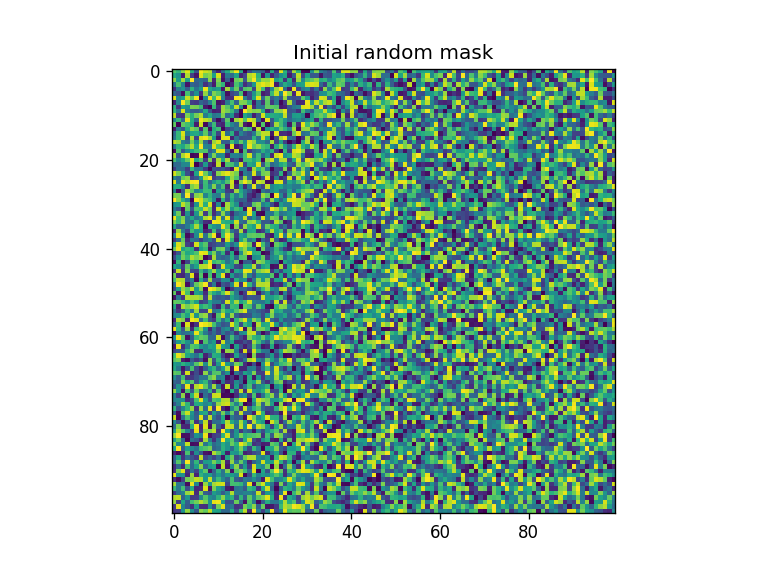

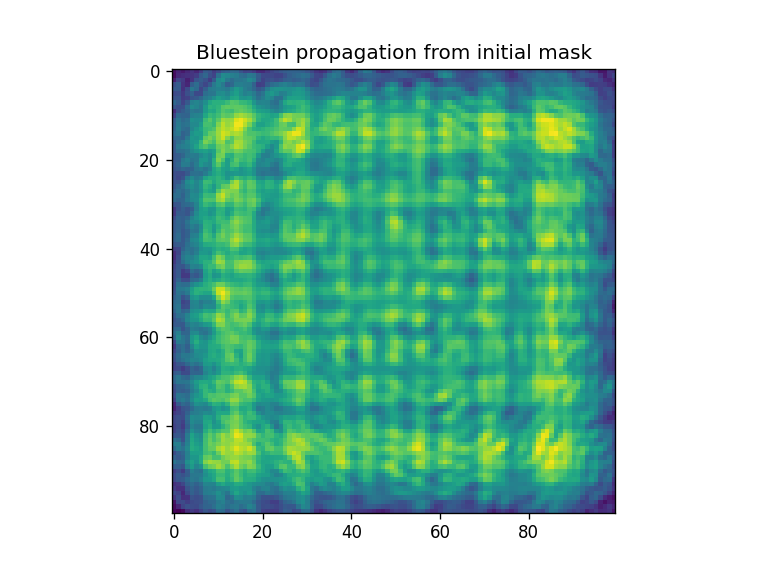

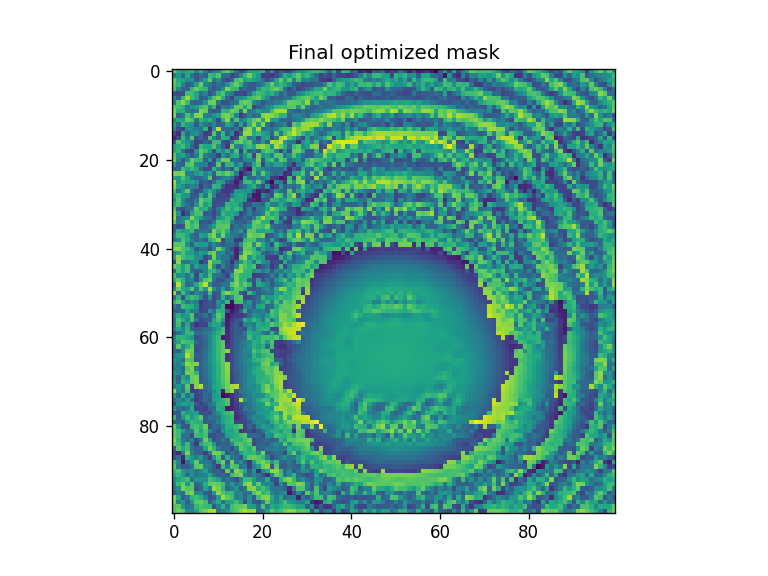

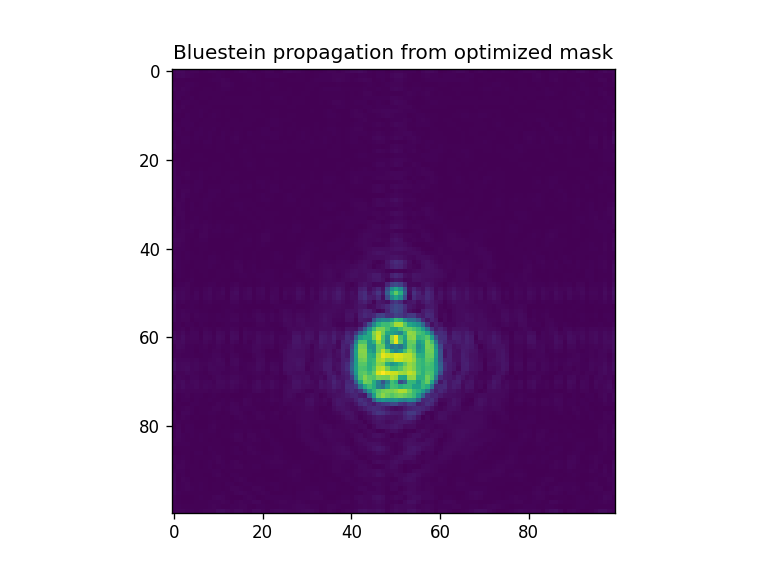

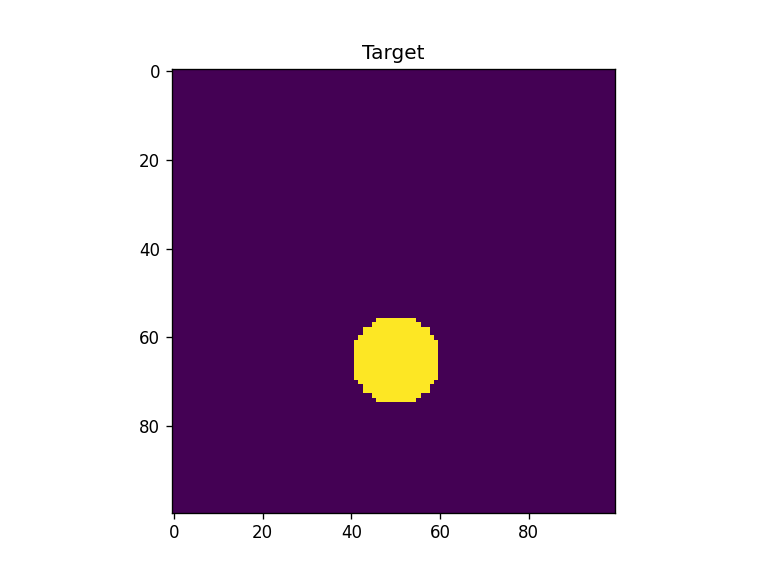

In [39]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial random mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.reshape(target, (x_pixel, y_pixel)) )
plt.title("Target")

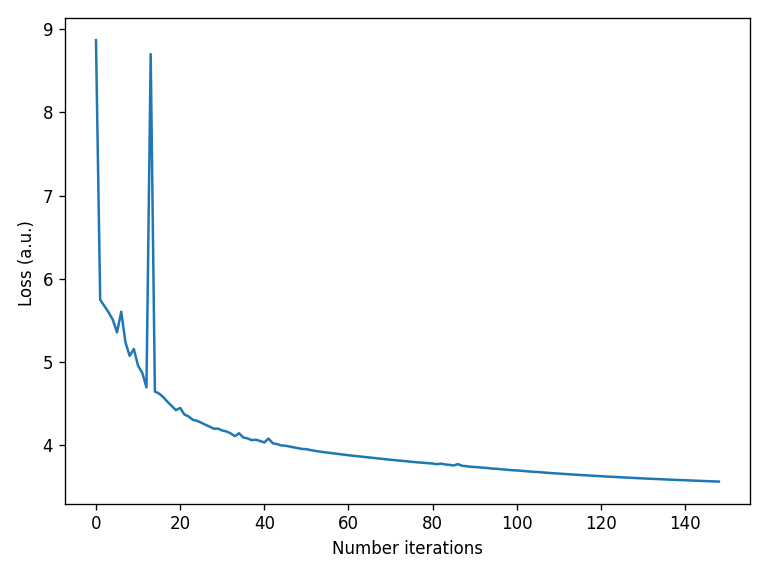

In [40]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Other optimizer algorithms 
By default the optimize function uses the 'trf' scipy algorithm. Here we exemplify 'dogbox' method as well. Other optimization algortihms can be used as well, namely all methods in scipy minimize, and 'adam' and 'rmsprop' from JAX' optax package. 

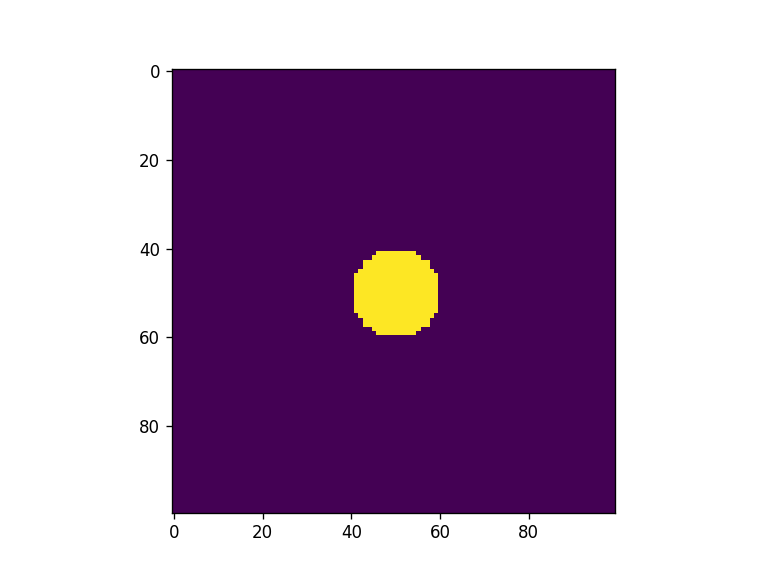

In [41]:
### Testing constant value initial guess 

#Initial guess
x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


#create target matrix (central cricular pattern) 
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)

target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.imshow(target)

Elapsed: 0:00:00.029371
Elapsed: 0:00:00.099563
Elapsed: 0:00:00.028373
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.067703
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.082637
Elapsed: 0:00:00.032856
Elapsed: 0:00:00.071187
Elapsed: 0:00:00.035844
Elapsed: 0:00:00.076166
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.068200
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.085624
Elapsed: 0:00:00.030864
Elapsed: 0:00:00.071187
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.027879
Elapsed: 0:00:00.078156
Elapsed: 0:00:00.027877
Elapsed: 0:00:00.067703
Elapsed: 0:00:00.032855
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.084133
Elapsed: 0:00:00.035347
Elapsed: 0:00:00.087114
Elapsed: 0:00:00.027903
Elapsed: 0:00:00.068200
Elapsed: 0:00:00

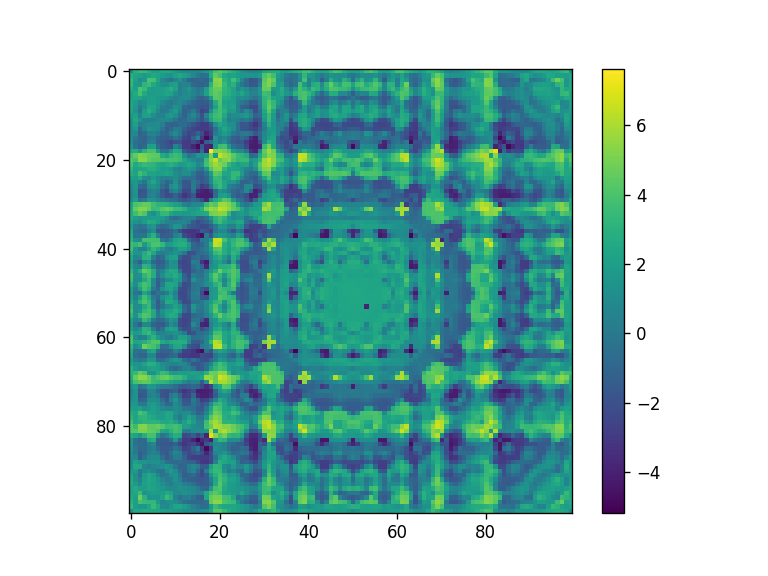

In [42]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen, wavelength, target, "ASM"), optimizer_method="dogbox", verbose=0, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.015930


Text(0.5, 1.0, 'ASM propagation from optimized mask')

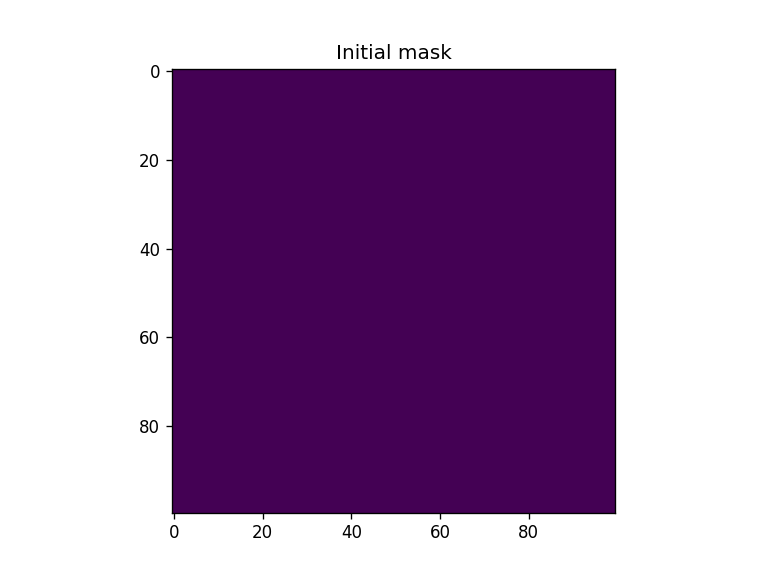

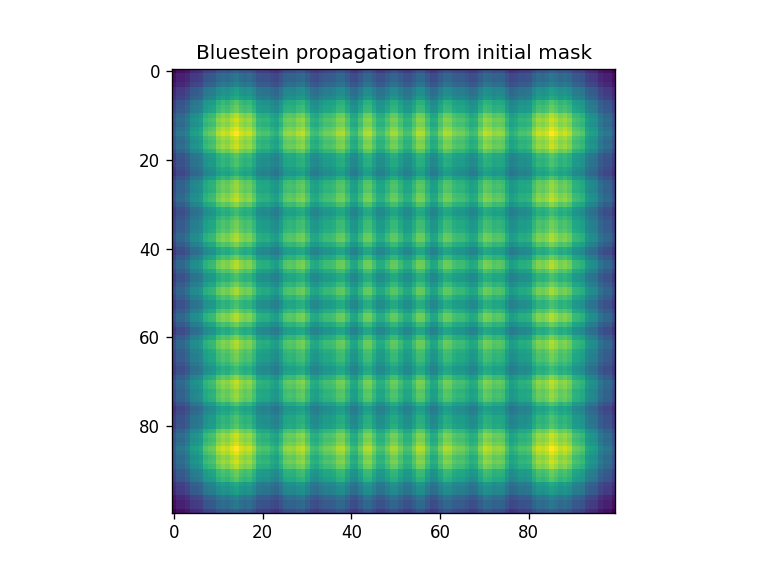

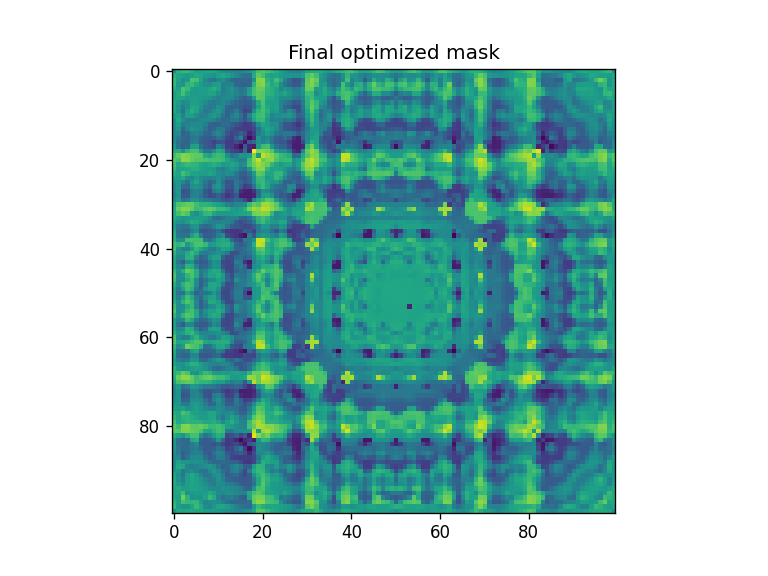

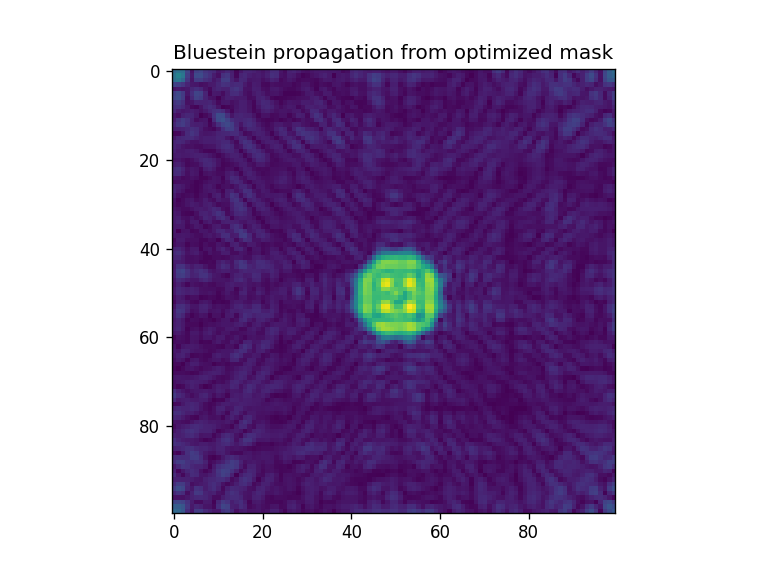

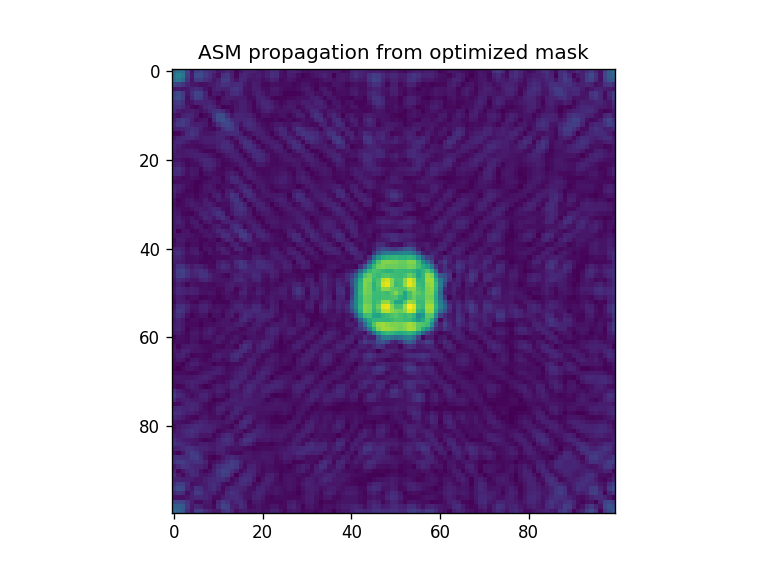

In [43]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength, "ASM") ) )
plt.title("ASM propagation from optimized mask")


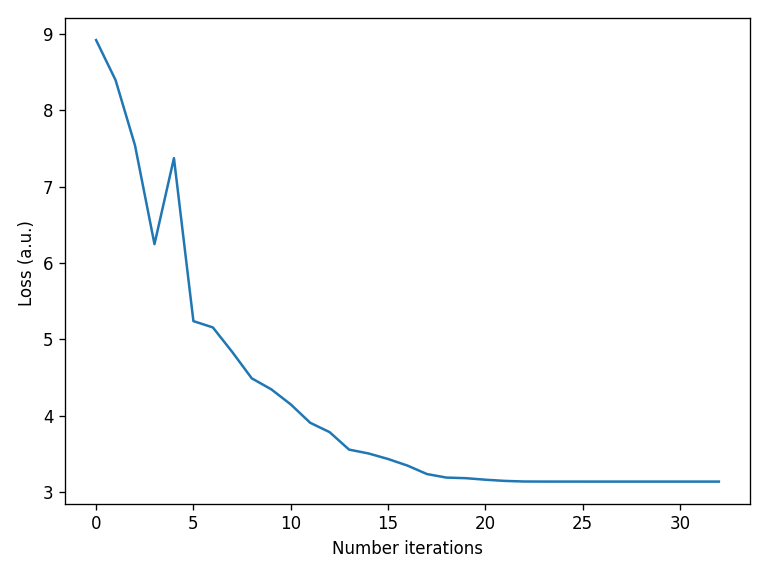

In [44]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

In [45]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

#solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen,wavelength),  optimizer_method="dual_annealing", \
#                                  tol=1 , minimizer_kwargs={"args":(aperture, screen, wavelength), "tol": 1 },  bounds = bounds)

#solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(aperture, screen),  optimizer_method="basinhopping", tol=1 ,\
#                                  minimizer_kwargs={"args":(aperture, screen), "tol": 1 },  bounds = bounds)

#solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(aperture, screen),  optimizer_method="differential_evolution", tol=1 ,\
#                                  minimizer_kwargs={"args":(aperture, screen), "tol": 1 },  bounds = bounds)

#### Optimization with 'optax' module optimizers  

In [46]:
solution = moe.optimizer.optimize(logloss2, x0_flatten, args1=(aperture, screen, wavelength, target, "ASM"), \
                                  optimizer_method="adam", verbose=0, ftol=1e-5)


Elapsed: 0:00:00.071187
Elapsed: 0:00:00.087116
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.088116
Elapsed: 0:00:00.070190
Elapsed: 0:00:00.079154
Elapsed: 0:00:00.083633
Elapsed: 0:00:00.092094
Elapsed: 0:00:00.084133
Elapsed: 0:00:00.070690
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.086620
Elapsed: 0:00:00.083135
Elapsed: 0:00:00.071683
Elapsed: 0:00:00.084133
Elapsed: 0:00:00.071188
Elapsed: 0:00:00.070191
Elapsed: 0:00:00.069695
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.087616
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.071190
Elapsed: 0:00:00.108524
Elapsed: 0:00:00.070194
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.071188
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.068698
Elapsed: 0:00:00.069695
Elapsed: 0:00:00.068201
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.092095
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.070687
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.070192
Elapsed: 0:00:00

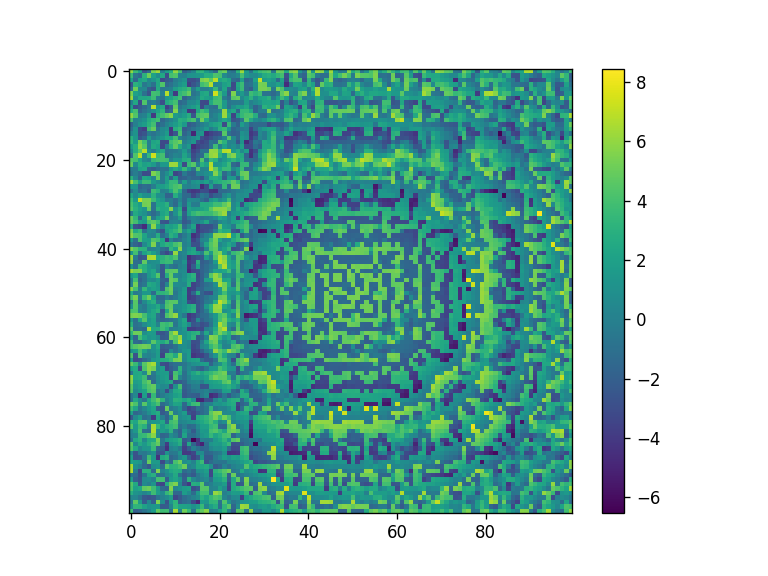

In [47]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015432
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014437


Text(0.5, 1.0, 'ASM propagation from optimized mask')

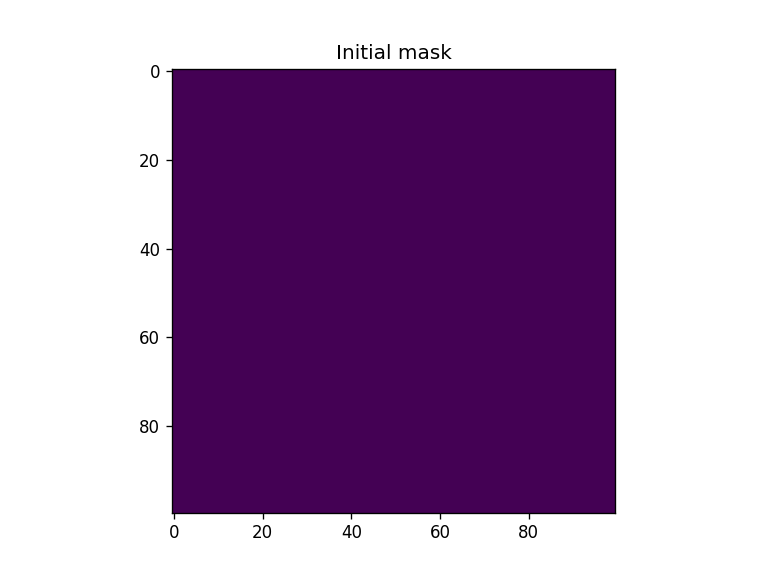

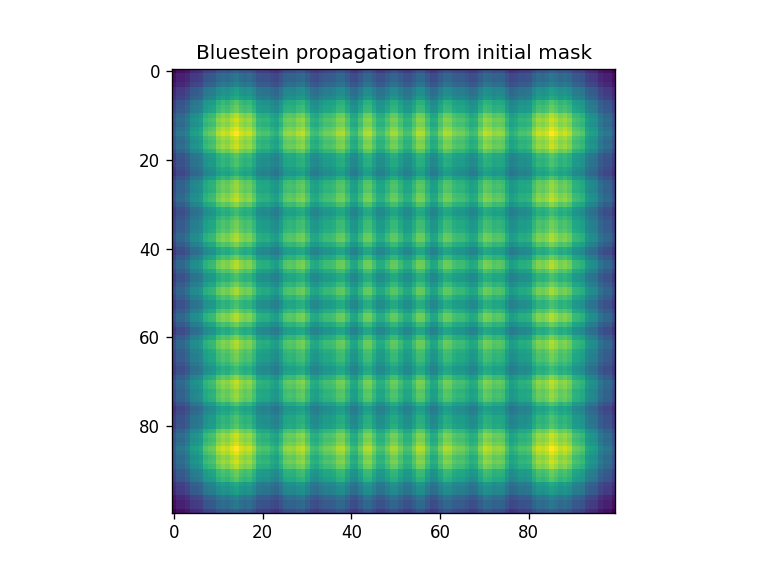

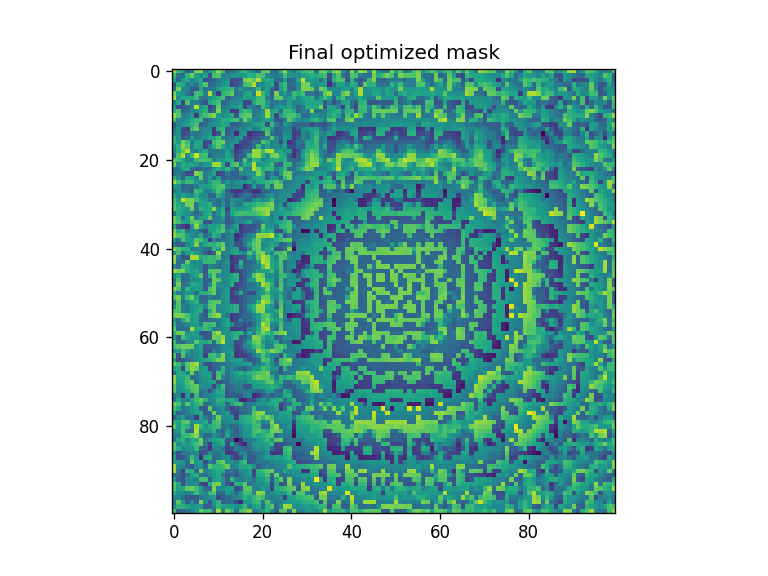

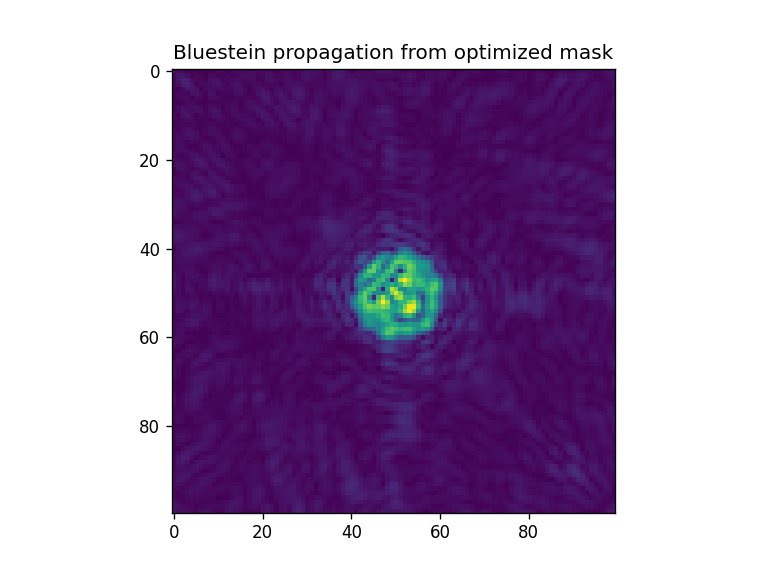

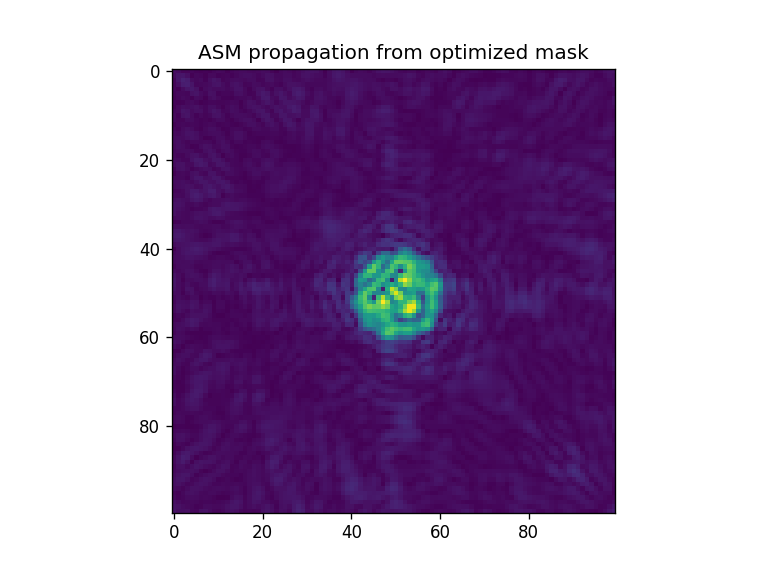

In [48]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 
plt.title("Initial mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from initial mask")


fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength, "ASM") ) )
plt.title("ASM propagation from optimized mask")


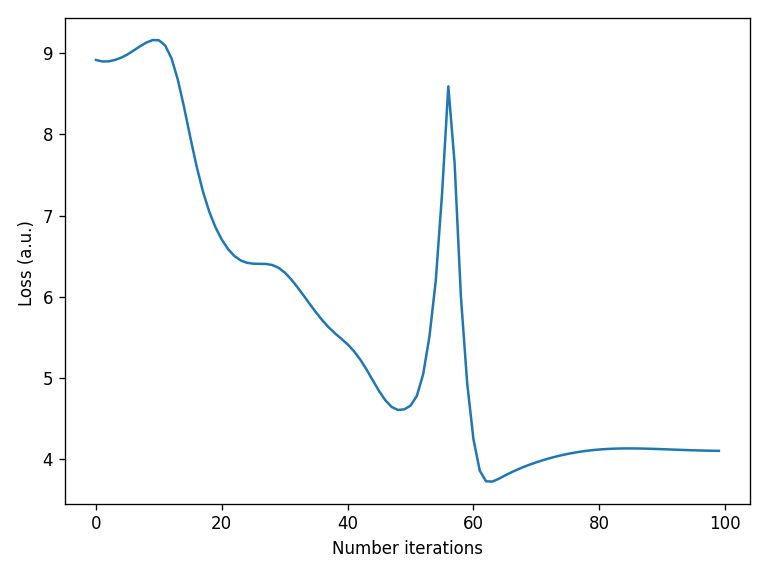

In [49]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

### Bounds during optimization  
By default the optimizers are unbound. Some can be bound, such as 'dogbox'.  

Elapsed: 0:00:00.015930
Elapsed: 0:00:00.061729
Elapsed: 0:00:00.020408
Elapsed: 0:00:00.039825
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.041817
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.014436
`xtol` termination condition is satisfied.
Function evaluations 13, initial cost 4.6493e-04, final cost 4.6454e-04, first-order optimality 5.01e-10.


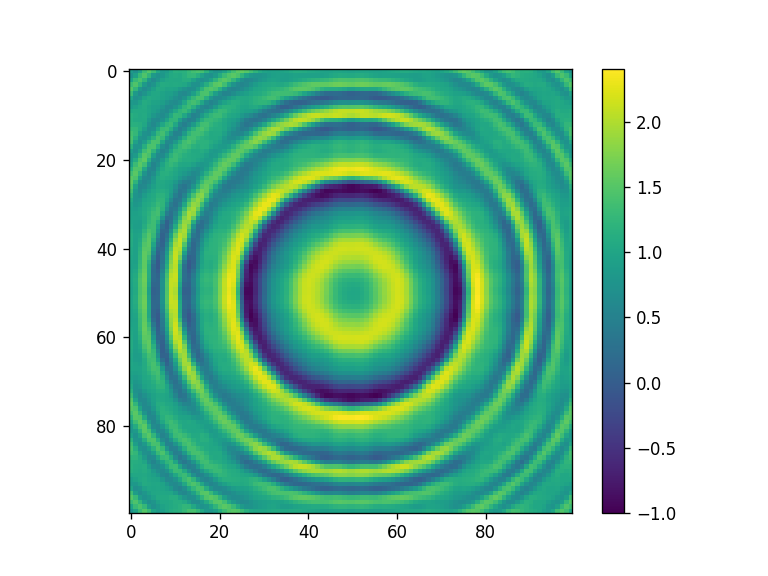

In [50]:
## Optimization with bounds 

solution = moe.optimizer.optimize(mseloss, x0_flatten, args1=(aperture, screen, wavelength, target, ), optimizer_method="dogbox", \
                                  bounds =(-1, 3), ftol = 1e-12 ,xtol=1e-12)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015432


Text(0.5, 1.0, 'Bluestein propagation from optimized mask')

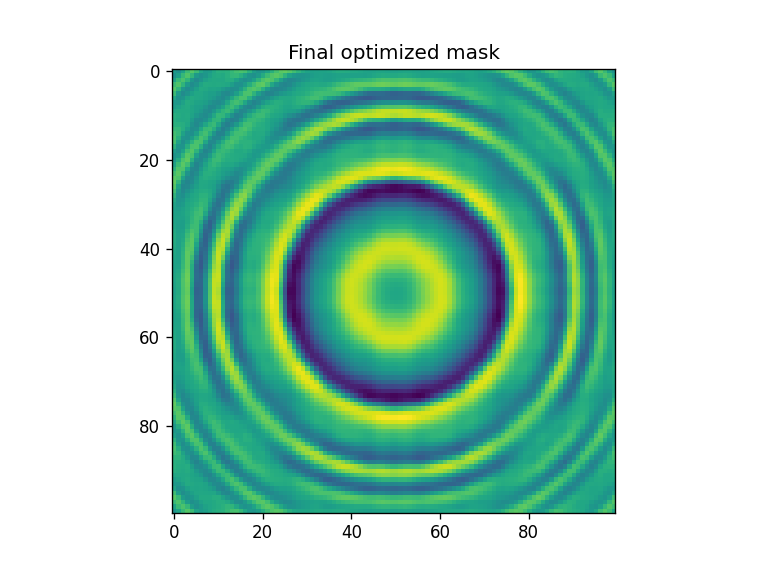

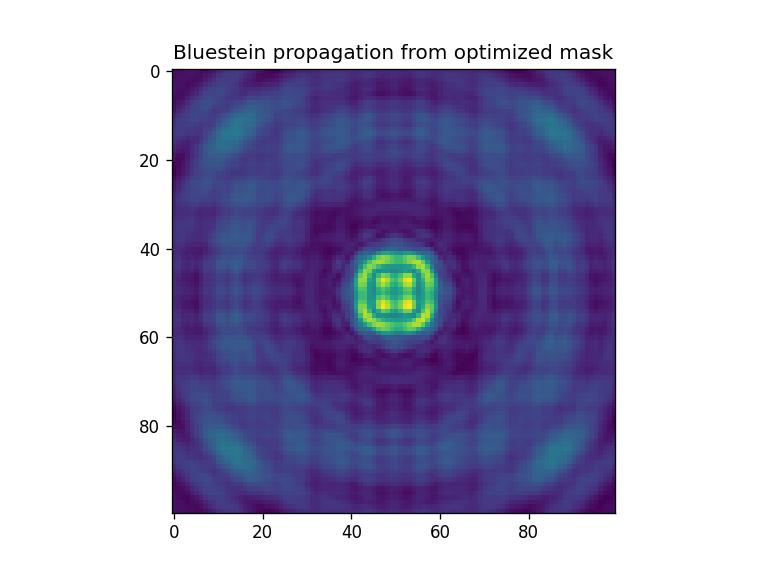

In [51]:
fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 
plt.title("Final optimized mask")

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture, screen, wavelength) ) )
plt.title("Bluestein propagation from optimized mask")


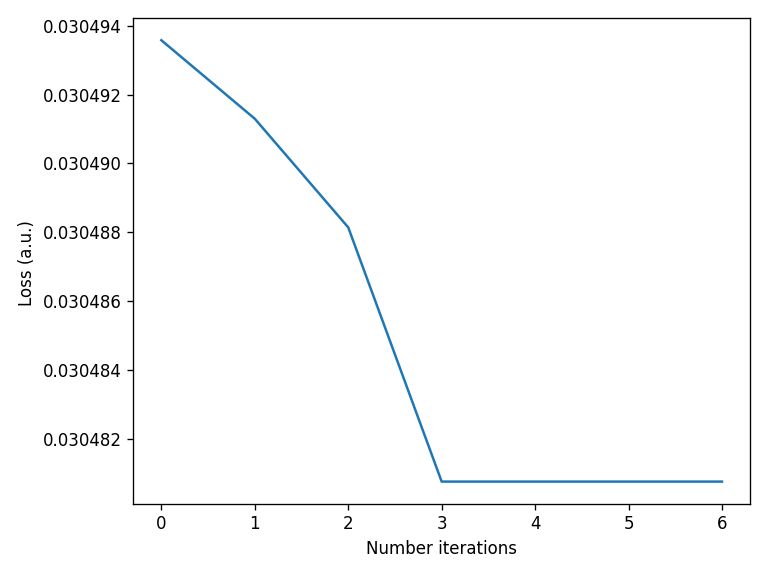

In [52]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

## Hologram creation via inverse design

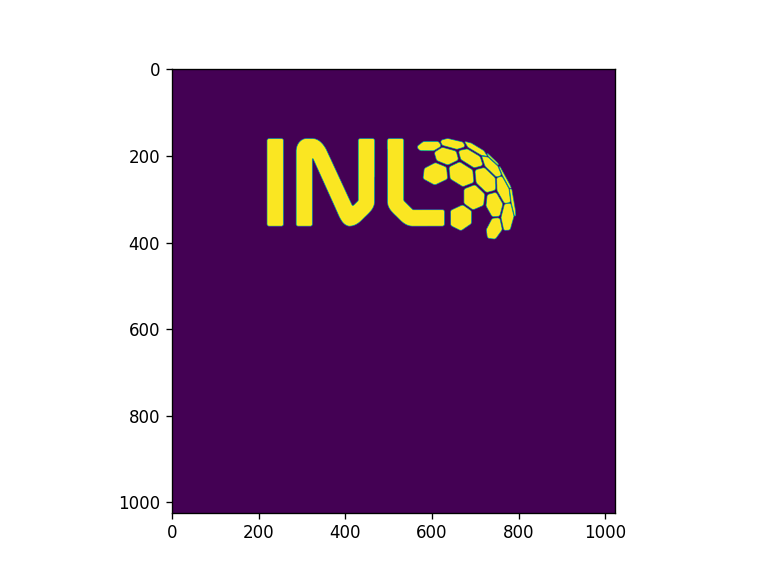

In [53]:
file = "../5 - Holograms/target.png"
targetread = plt.imread(file)

x_pixel, y_pixel = np.shape(targetread)

xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi, indexing = 'ij')
    

fig = plt.figure() 
plt.imshow(targetread)


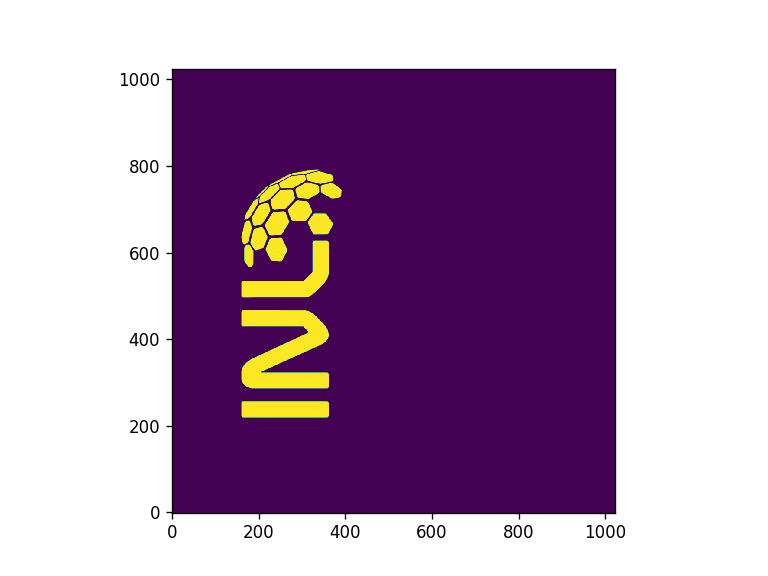

In [54]:
fig = plt.figure() 
plt.pcolormesh(XX,YY,targetread)
plt.gca().set_aspect('equal')

**IMPORTANT** the target is read as represented in the pcolormesh above in the ij indexing convention (used throughout the calculations). Hence, to have the correct representation, the axes need to be transformed.  

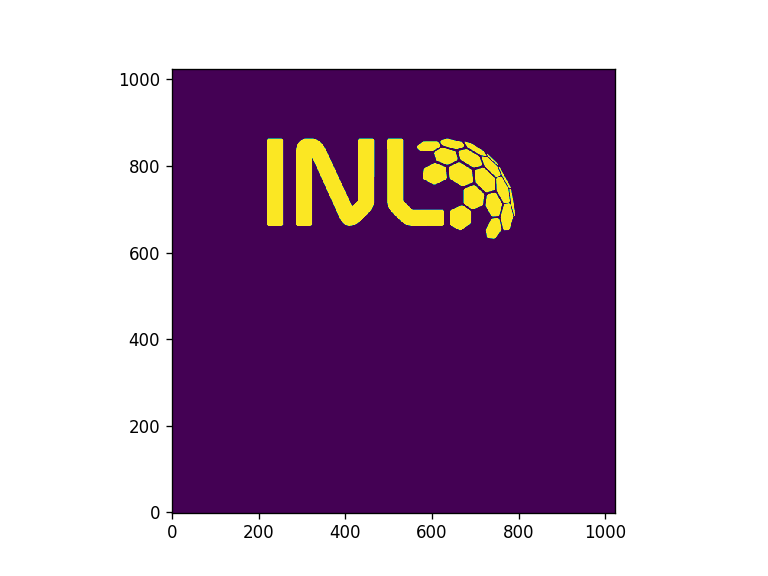

In [55]:
target = np.flip(np.rot90(targetread))

fig = plt.figure() 
plt.pcolormesh(XX,YY,target)
plt.gca().set_aspect('equal')

In [56]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


In [57]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

s = 0.2 

x = np.linspace(xmin*s, xmax*s, x_pixel)
y = np.linspace(ymin*s, ymax*s, y_pixel)
z = np.array([ s ])


screen = moe.Screen(x,y,z)

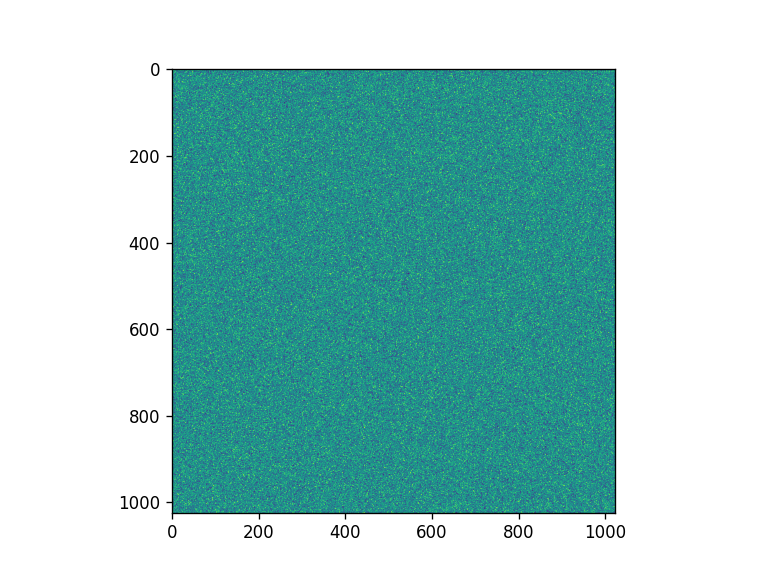

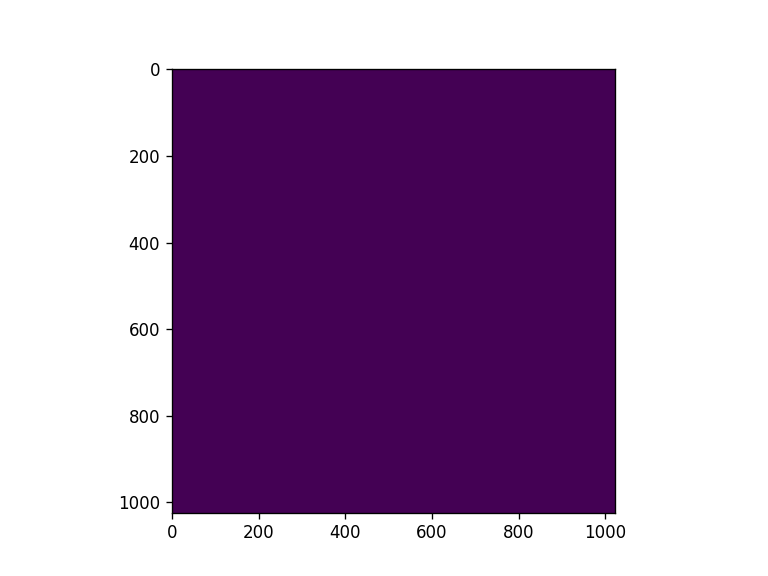

In [58]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

In [59]:
def mselossmax(x, mask, screen, wavelength, target, propag="bluestein", pad=2): 
    import jax.numpy as jnp 
    
    prop_x =  jnp.abs(moe.optimizer.propagate(jnp.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength,\
                                             propagation_method=propag, pad_factor=pad))**2

    diff = jnp.abs(prop_x/jnp.max(prop_x) - target/jnp.max(target))**2
     
    res = jnp.sum(diff)
    return res

In [60]:
solution = moe.optimizer.optimize(mselossmax, x0= xvalues.flatten(), args1=[aperture1, screen, wavelength, target], verbose = 1, ftol=1e-6, xtol=None,\
                                  optimizer_method='dogbox' )


x2 = solution.x


Elapsed: 0:00:02.051994
Elapsed: 0:00:01.340617
Elapsed: 0:00:00.597380
Elapsed: 0:00:00.757675
Elapsed: 0:00:00.586427
Elapsed: 0:00:00.762156
Elapsed: 0:00:00.571495
Elapsed: 0:00:00.779579
Elapsed: 0:00:00.593896
Elapsed: 0:00:00.755684
Elapsed: 0:00:00.576472
Elapsed: 0:00:00.755684
Elapsed: 0:00:00.594889
Elapsed: 0:00:00.728302
Elapsed: 0:00:00.570498
Elapsed: 0:00:00.769626
Elapsed: 0:00:00.598375
Elapsed: 0:00:00.737264
Elapsed: 0:00:00.560045
Elapsed: 0:00:00.795012
Elapsed: 0:00:00.555067
Elapsed: 0:00:00.709885
Elapsed: 0:00:00.558547
Elapsed: 0:00:00.725816
Elapsed: 0:00:00.562037
Elapsed: 0:00:00.703414
Elapsed: 0:00:00.562535
Elapsed: 0:00:00.705904
Elapsed: 0:00:00.551579
Elapsed: 0:00:00.562531
Elapsed: 0:00:00.734279
Elapsed: 0:00:00.575975
Elapsed: 0:00:00.703415
Elapsed: 0:00:00.555064
Elapsed: 0:00:00.546601
Elapsed: 0:00:00.724320
Elapsed: 0:00:00.581945
Elapsed: 0:00:00.768626
Elapsed: 0:00:00.548592
Elapsed: 0:00:00.719843
Elapsed: 0:00:00.577466
Elapsed: 0:00:00

Elapsed: 0:00:00.561037


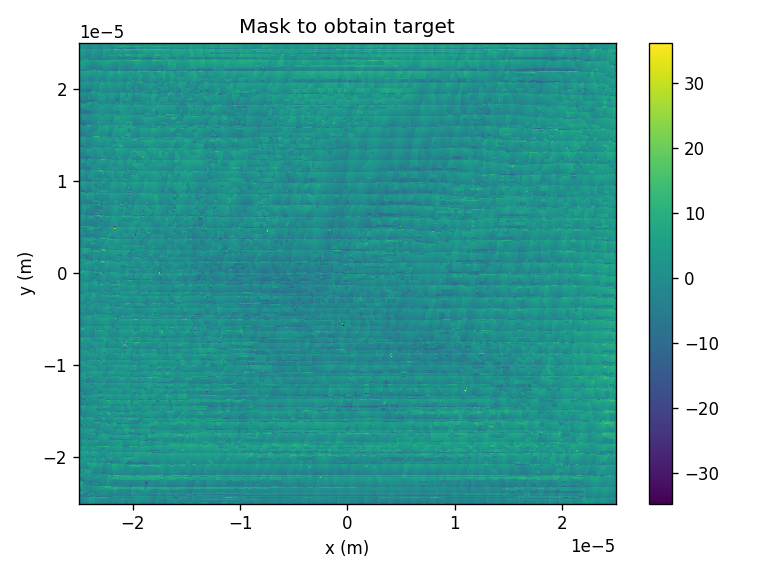

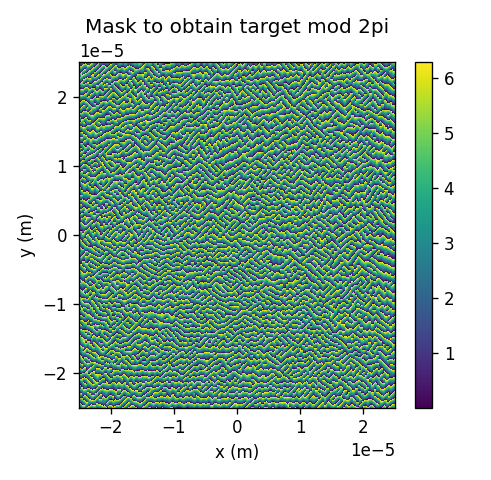

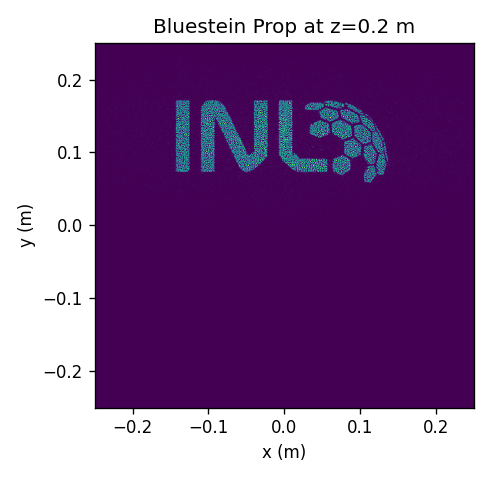

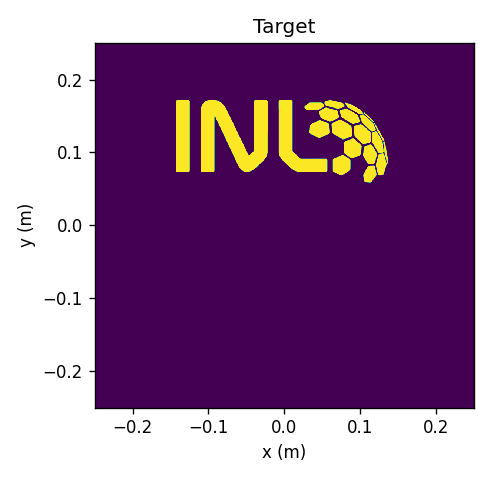

In [61]:
xar3 = (np.reshape(x2, (x_pixel, y_pixel)))

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

fig = plt.figure() 

plt.pcolormesh(aperture1.XX, aperture1.YY, xar3) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(aperture1.XX, aperture1.YY, (xar3)%(2*np.pi) )
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.XX[:,:,-1], screen.YY[:,:,-1], np.abs(moe.optimizer.propagate(xar3, aperture1, screen, wavelength) )**2 )
#plt.imshow(np.abs(moe.optimizer.propagate(xar3, aperture1, screen, wavelength) )**2 )
plt.title("Bluestein Prop at z="+str(screen.z[-1])+" m")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.XX[:,:,-1], screen.YY[:,:,-1], (np.reshape(target, (x_pixel, y_pixel)) )) 
#plt.imshow(target)
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

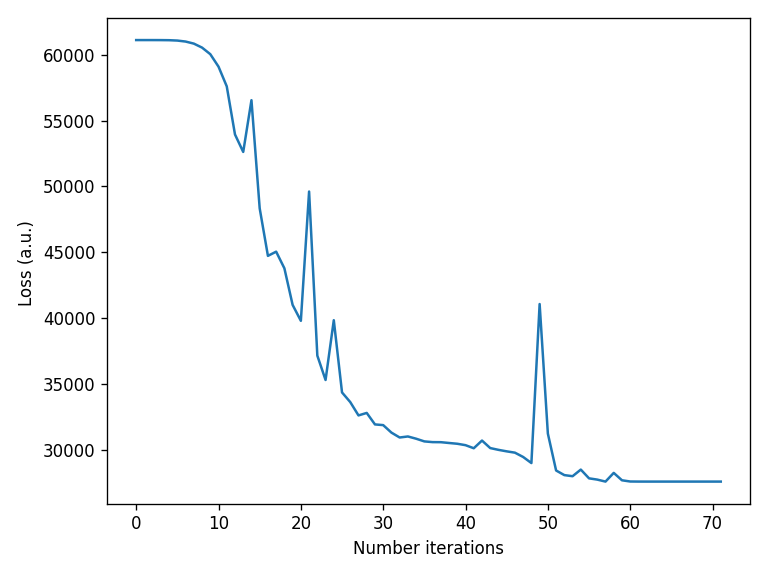

In [62]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 

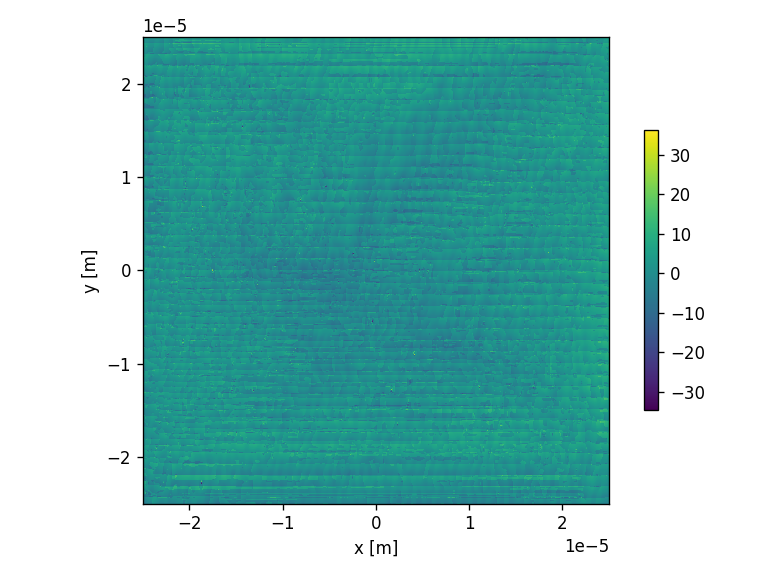

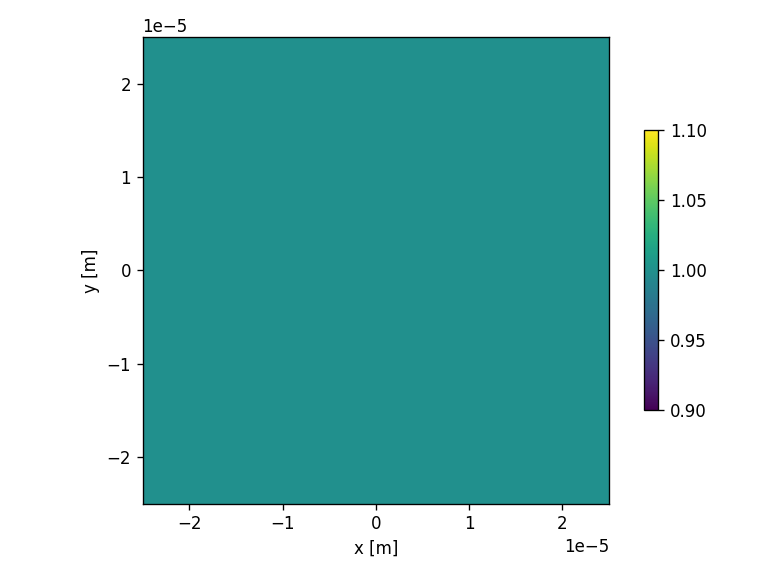

Progress: [####################] 100.0%
Elapsed: 0:00:00.990156


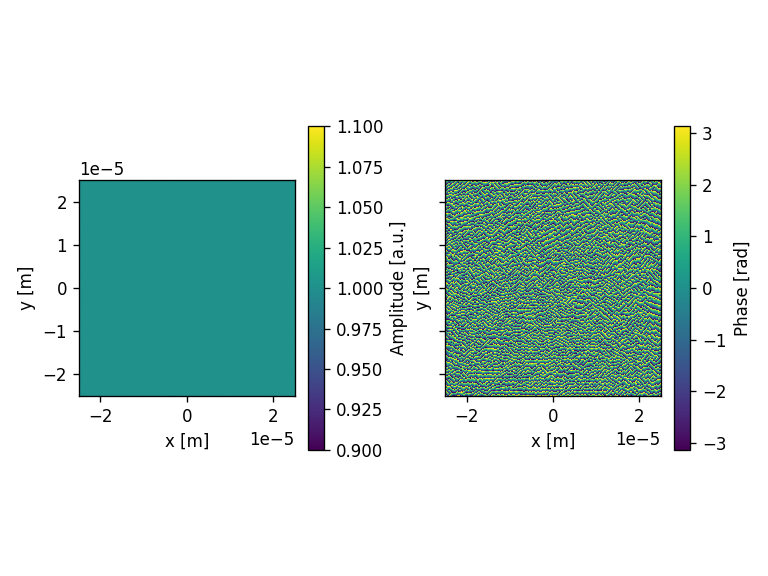

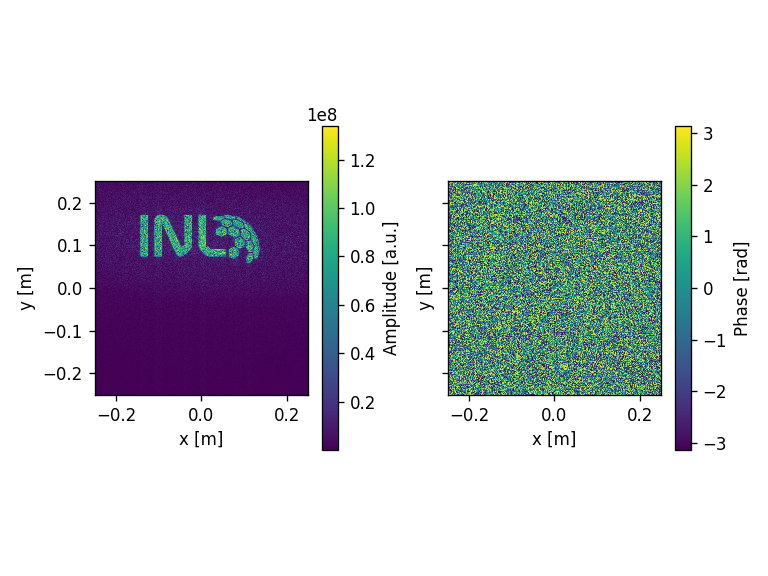

In [63]:
screen = moe.Screen(x,y,z)

# Define Aperture
aperture = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
mask_amplitude = moe.generate.create_empty_aperture_from_aperture(aperture)

# Define Phase mask 
mask_phase = moe.generate.create_empty_aperture_from_aperture(aperture)
mask_phase.aperture = xar3 

#mask_phase.aperture =  np.flipud(np.rot90(xar3)) ##use need to 

mask_amplitude.aperture = mask_amplitude.aperture +1 

# Plot the circular mask
moe.plotting.plot_aperture(mask_phase)
moe.plotting.plot_aperture(mask_amplitude)

# Calculates a field to use with the calculated mask

# Initialize a Field from the Aperture mask 
field = moe.field.create_empty_field_from_aperture(mask_phase)
# Generate a uniform field
field = moe.field.generate_uniform_field(field, E0=1)


# Modulates the field with a given aperture that can be used either as an amplitude mask or a phase mask
field = moe.field.modulate_field(field, amplitude_mask=mask_amplitude, phase_mask=mask_phase)
# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)


# Propagate the field with Bluestein 
EXYZ = moe.propagate.Bluestein(field, screen, wavelength)
moe.plotting.plot_screen_XY(EXYZ, z=s)

AGAIN, **BEWARE all imshow will show rotated+flipped matrices, e.g. the optimization result shown below appers flipped and rotated**!!! 

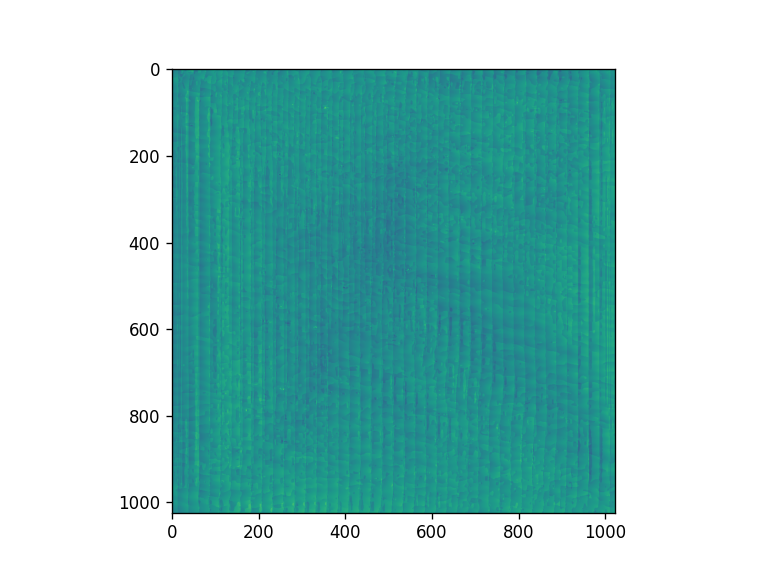

In [64]:
plt.figure() 
plt.imshow(xar3)

# Optimization of ensembles of optical elements 

In [67]:
###Import two surfaces - doublet 

#number of pixels 
x_pixel = 100
y_pixel = 100

a1_phase = np.random.rand(x_pixel, y_pixel) #np.genfromtxt("asph1_phase.csv", delimiter=',')
a1_inten = a1_phase * 0 #np.genfromtxt("asph1_inten.csv", delimiter=',')

a2_phase = np.random.rand(x_pixel, y_pixel) #np.genfromtxt("asph2_phase.csv", delimiter=',')
a2_inten = a2_phase * 0 #np.genfromtxt("asph2_inten.csv", delimiter=',')



#size of the rectangular mask 
aperture_width  = 800e-6 #m
aperture_height = 800e-6

pixsize = 8e-6 #m

wavelength = 550e-9 

dist1 = 40e-3 
dist2 = 50e-3

zmin1 = wavelength
zmax1 = dist1
nzs = 2

zmin2 = wavelength
zmax2 = dist2
nzs = 2

radius = aperture_width/2 


asph1_mask_phase = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
asph1_mask_phase.aperture = a1_phase

asph1_mask_inten = moe.generate.create_empty_aperture_from_aperture(asph1_mask_phase)
asph1_mask_inten.aperture = a1_inten

asph2_mask_phase = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)
asph2_mask_phase.aperture = a2_phase

asph2_mask_inten = moe.generate.create_empty_aperture_from_aperture(asph2_mask_phase)
asph2_mask_inten.aperture = a2_inten

aperture = moe.generate.create_empty_aperture_from_aperture(asph2_mask_phase)
mask = moe.generate.circular_aperture(aperture, radius=radius*10)

aperture_array_phase = [asph1_mask_phase, asph2_mask_phase]
aperture_array_amp = [mask,]*len(aperture_array_phase)

############################
## Define the screens 
x1 = asph1_mask_phase.x
y1 = asph1_mask_phase.y
z1 = np.linspace(zmin1, zmax1, nzs)

screen1 = moe.field.Screen(x1,y1,z1)

x2 = asph2_mask_phase.x
y2 = asph2_mask_phase.y
z2 = np.linspace(zmin2, zmax2, nzs)

screen2 = moe.field.Screen(x2,y2,z2)


screen_array = [screen1, screen2]

##################################
#Wavelengths 
wavelength_array = [wavelength]

###############################
#input field 

field_input = moe.field.create_empty_field_from_aperture(aperture)
field_input = moe.field.generate_uniform_field(field_input, E0=1)
input_light_field = field_input

##create ensemble 
ensemble = moe.ensemble.Ensemble(aperture_array_amp, aperture_array_phase, screen_array,  wavelength_array, input_light_field)

Assuming the Apertures to contain already the actual phases of the objects.


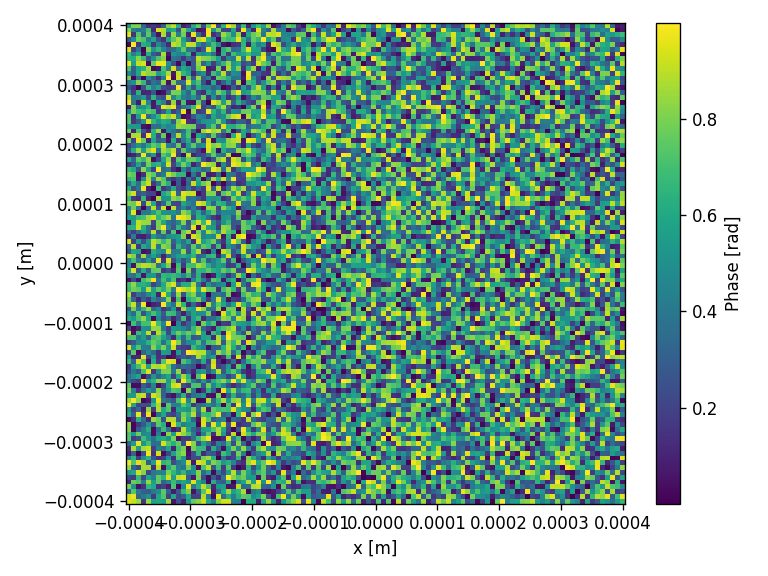

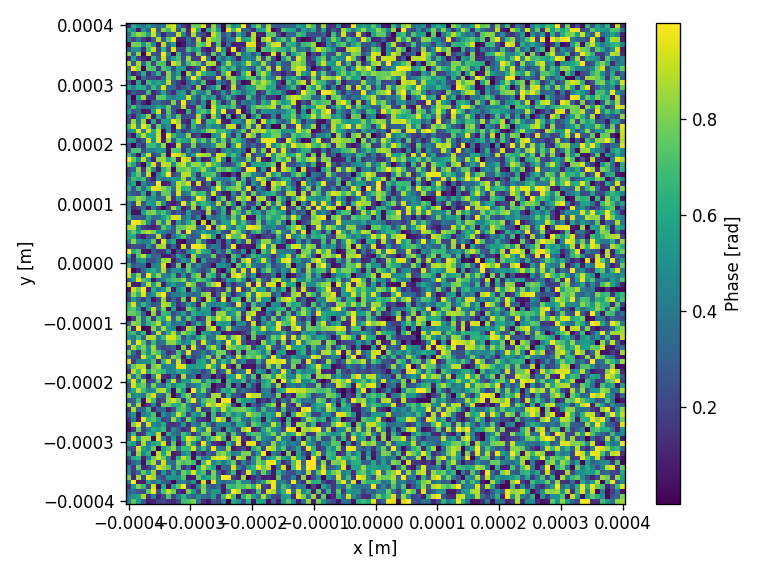

In [68]:
#the initial arrays are two random matrices represented below 

fig = plt.figure() 
plt.pcolormesh(aperture_array_phase[0].XX, aperture_array_phase[0].YY, aperture_array_phase[0].aperture)
plt.colorbar(label ="Phase [rad]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.tight_layout()

fig = plt.figure() 
plt.pcolormesh(aperture_array_phase[1].XX, aperture_array_phase[1].YY, aperture_array_phase[1].aperture)
plt.colorbar(label ="Phase [rad]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.tight_layout() 

Surface #1
Progress: [####################] 100.0%
Elapsed: 0:00:00.009459
Surface #2
Progress: [####################] 100.0%
Elapsed: 0:00:00.010455


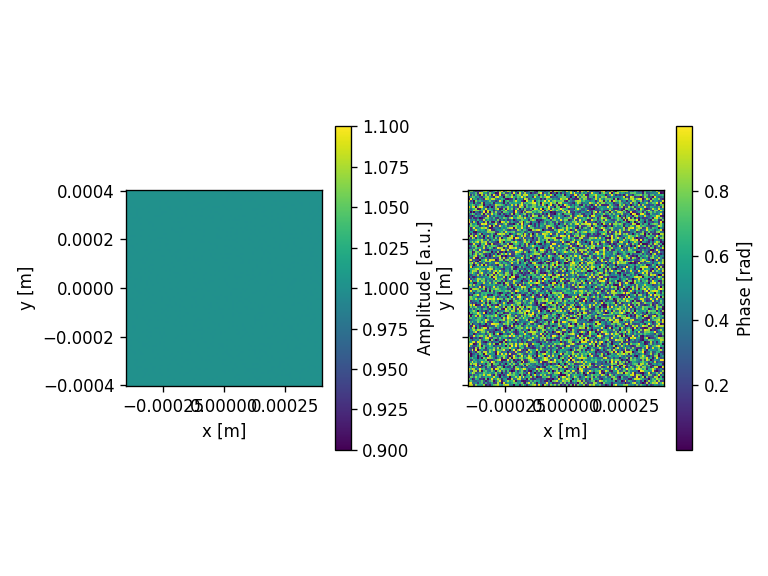

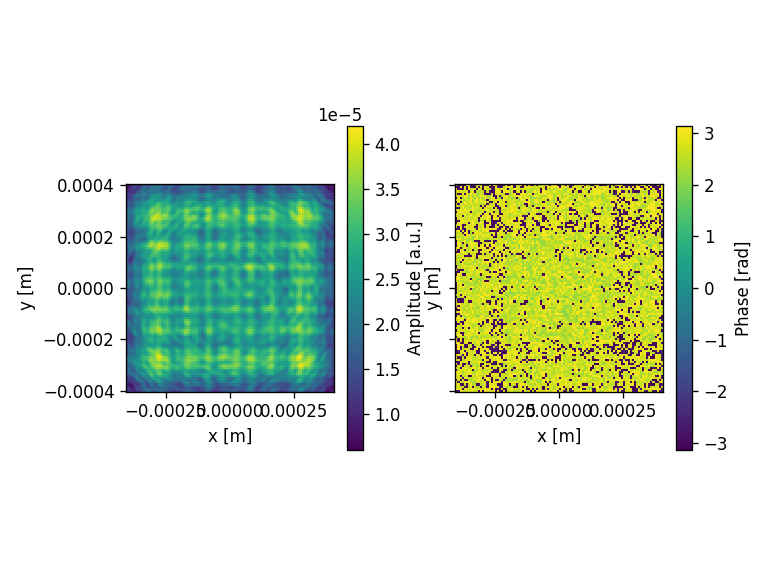

In [69]:
prop_methods = ["bluestein", "bluestein"]
EXY_array2 = [moe.propagate.propagate_through_ensemble(ensemble, wavelength, propagation_methods_array=prop_methods) for wavelength in wavelength_array]

In [70]:
x0_flatten = (np.array([aperture_array_phase[0].aperture.flatten(), aperture_array_phase[1].aperture.flatten()]) ).flatten()
x0_flatten.shape, a1_phase.shape 

((20000,), (100, 100))

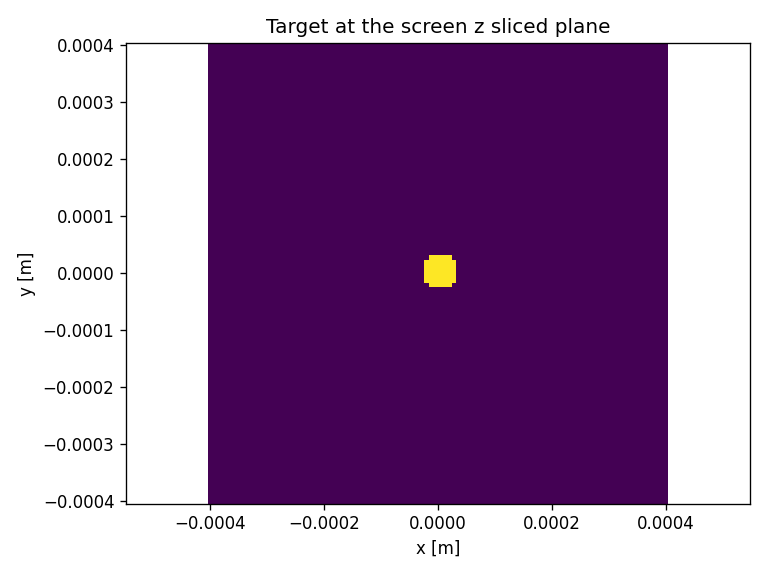

In [71]:
xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi, indexing='ij')
    
target = np.zeros((x_pixel, y_pixel))
target[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-0)**2) < 4**2)] = 1 

target_flat = target.flatten()

fig = plt.figure() 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], target )
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Target at the screen z sliced plane")
plt.tight_layout() 

In [72]:
def loss(x, mask, screen_array, wavelength, target, propag="bluestein"): 
    import jax.numpy as jnp 
    
    #prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    xar1 = jnp.reshape(x[0:int(len(x)/2)], (len(screen_array[0].x), len(screen_array[0].y)))
    xar2 = jnp.reshape(x[int(len(x)/2):], (len(screen_array[0].x), len(screen_array[0].y)))
    xar=[xar1, xar2]
    
    prop_x = moe.optimizer.propagate(xar, aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["ASM","ASM"], pad_factor=2, modedef = "czt", ensemble_mode=True , corr=1e5  )**2
    
    
    diff = jnp.abs(prop_x/jnp.sum(prop_x) - target/jnp.max(target))**2
     
    res = np.sum(diff)

    return res

In [73]:
solution = moe.optimizer.optimize(loss, x0_flatten, args1=[aperture, screen_array, wavelength, target, ], verbose = 1, ftol=1e-4,)

x = solution.x

Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:01.396873
Elapsed: 0:00:00.066209
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.637702
Elapsed: 0:00:00.126941
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.062226
Elapsed: 0:00:00.049285
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.109020
Elapsed: 0:00:00.100561
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.056252
Elapsed: 0:00:00.048288
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.108524
Elapsed: 0:00:00.109024
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.062725
Elapsed: 0:00:00.048786
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.048787
Elapsed: 0:00:00.044308
Assuming

Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.098572
Elapsed: 0:00:00.077661
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.031363
Elapsed: 0:00:00.045303
Assuming the Apertures to contain already the actual phases of the objects.
Elapsed: 0:00:00.044306
Elapsed: 0:00:00.068696


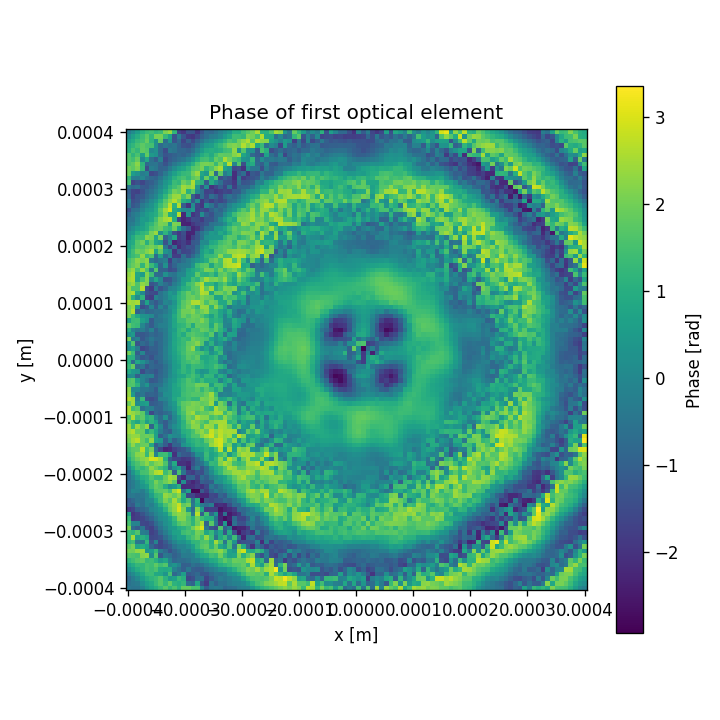

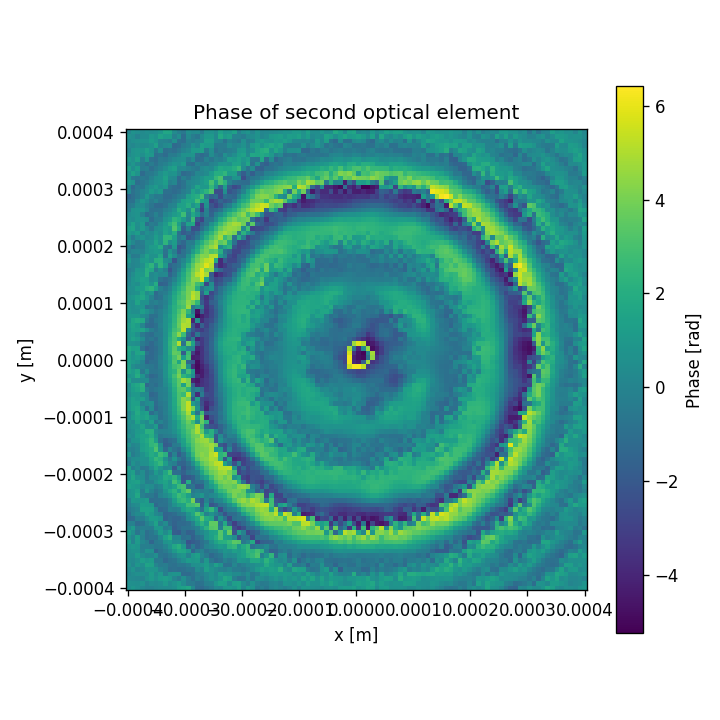

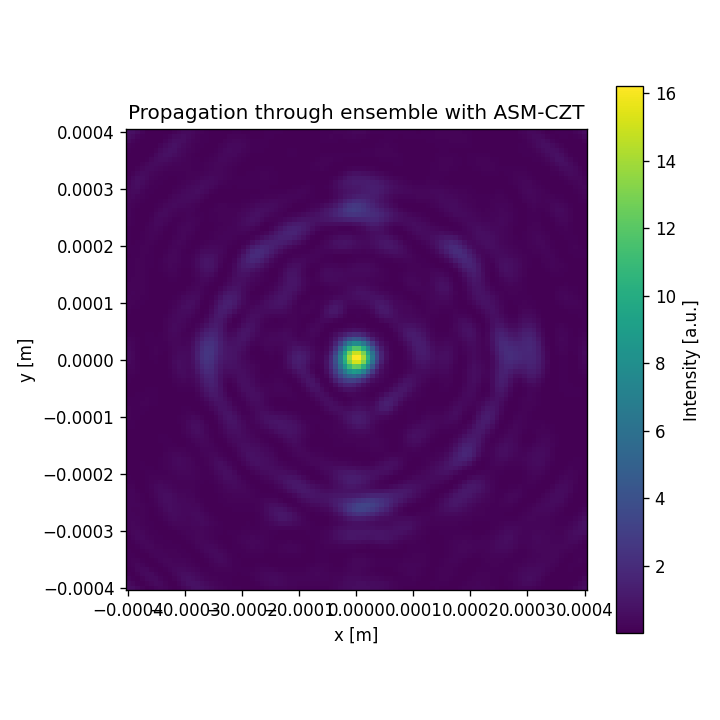

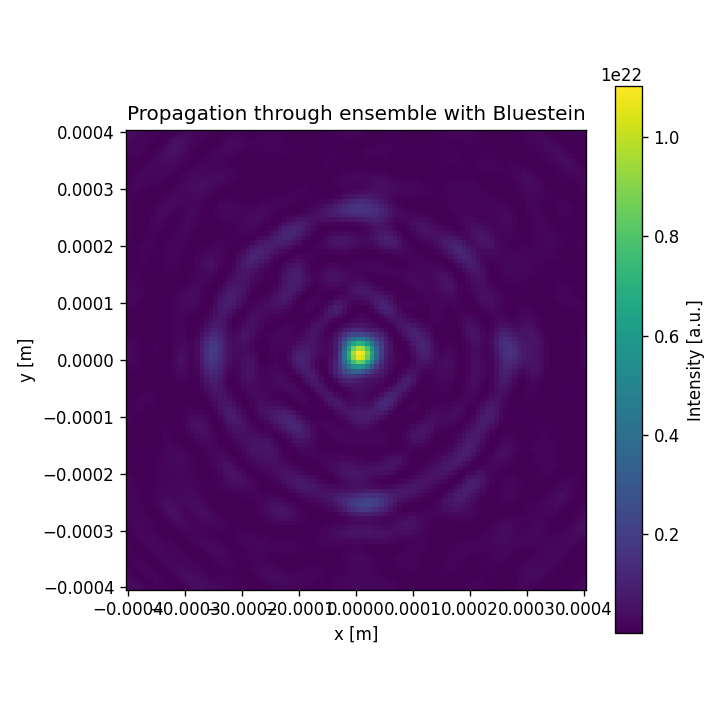

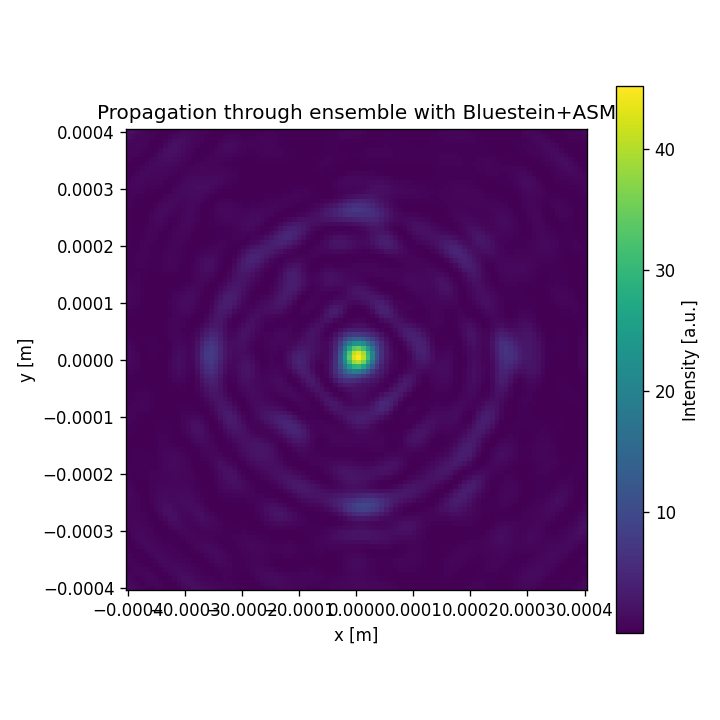

In [74]:
d1 = np.reshape(x[0:int(len(x)/2)], (len(screen_array[0].x), len(screen_array[0].y)))
d2 = np.reshape(x[int(len(x)/2):], (len(screen_array[0].x), len(screen_array[0].y)))

fig = plt.figure(figsize = (6,6)) 
xar3 = np.reshape(d1, (x_pixel, y_pixel))
plt.pcolormesh(aperture_array_phase[0].XX, aperture_array_phase[0].YY, xar3)
plt.colorbar(label = "Phase [rad]", shrink=0.8)
plt.title("Phase of first optical element")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

fig = plt.figure(figsize = (6,6)) 
xar4 = np.reshape(d2, (x_pixel, y_pixel))
plt.pcolormesh(aperture_array_phase[1].XX, aperture_array_phase[1].YY, xar4)
plt.colorbar(label = "Phase [rad]", shrink=0.8)
plt.title("Phase of second optical element")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["ASM","ASM"], pad_factor=2, modedef = "czt", ensemble_mode=True  )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with ASM-CZT")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["bluestein","bluestein"], pad_factor=2,  ensemble_mode=True , corr=1e10 )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with Bluestein")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

Ep = moe.optimizer.propagate(xar=[d1, d2], aperture=aperture_array_phase, screen=screen_array , wavelength=wavelength_array, \
          mask_amp = aperture_array_amp, circ_radius=None, input_field="uniform", E0=1, \
          propagation_method=["bluestein","ASM"], pad_factor=2,  ensemble_mode=True , corr=1e10 )

fig = plt.figure(figsize = (6,6)) 
plt.pcolormesh(screen_array[-1].XX[:,:,-1], screen_array[-1].YY[:,:,-1], (np.abs(Ep) )**2)
plt.colorbar(label = "Intensity [a.u.]", shrink=0.8)
plt.title("Propagation through ensemble with Bluestein+ASM")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout() 

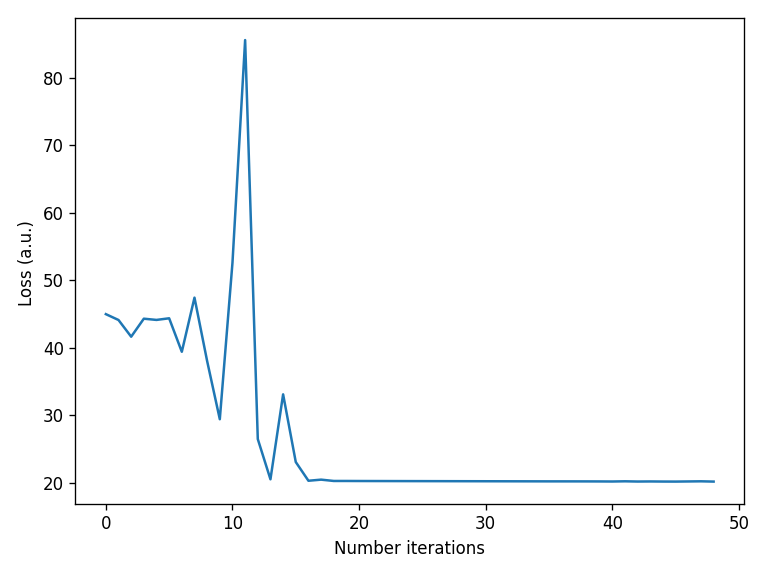

In [75]:
loss_vector = solution.loss_history 

plt.figure() 
plt.plot(loss_vector)
plt.xlabel("Number iterations")
plt.ylabel("Loss (a.u.) ")
plt.tight_layout() 